# VTT Pipeline - Output Analysis

This notebook discovers all output folders matching `OUTPUT_TITLE + "_CT_*"`, reports what is present or missing, and visualizes each major pipeline stage.

Use the setup cell below as the control panel: change the output title, plot behavior, color maps, SPECT frame selection, and comparison filters there before rerunning the notebook.


## 1 - Imports, Plot Helpers, and Unit Helpers

Expected output: a short `Imports OK` message. This cell defines reusable helpers only; it does not load patient data.


In [57]:
import os
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from scipy.optimize import curve_fit, OptimizeWarning

plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'figure.titlesize': 16,
    'figure.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 100,
})


def _strip_comments(text):
    # Some repo JSON files allow // comments. Strip them before json.loads.
    lines = []
    for line in text.splitlines():
        idx = line.find('//')
        lines.append(line[:idx] if idx >= 0 else line)
    return '\n'.join(lines)


def load_json(path):
    with open(path, encoding='utf-8') as f:
        return json.loads(_strip_comments(f.read()))


def list_files(directory, suffix):
    if not os.path.isdir(directory):
        return []
    return sorted(os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(suffix))


def stem(path):
    name = os.path.basename(path)
    return name[:-7] if name.endswith('.nii.gz') else os.path.splitext(name)[0]


def fmt_int(value):
    try:
        return f'{int(value):,}'
    except Exception:
        return str(value)


def pct(numer, denom, eps=1e-9):
    return (numer - denom) / (abs(denom) + eps) * 100.0


def safe_name(text):
    name = re.sub(r'[^A-Za-z0-9_.-]+', '_', str(text)).strip('_')
    return name or 'plot'


def finish_plot(fig, name, tight=True):
    # Shared show/save behavior. Configure SHOW_PLOTS and SAVE_PLOTS in the next cell.
    if tight:
        fig.tight_layout()
    saved_paths = []
    if globals().get('SAVE_PLOTS', False):
        out_dir = Path(globals().get('PLOT_OUTPUT_DIR', 'notebook_plots'))
        out_dir.mkdir(parents=True, exist_ok=True)
        for ext in globals().get('PLOT_FORMATS', ('png',)):
            out_path = out_dir / f'{safe_name(name)}.{ext}'
            fig.savefig(out_path, dpi=globals().get('PLOT_DPI', 200), bbox_inches='tight')
            saved_paths.append(out_path)
        if globals().get('PRINT_SAVED_PLOTS', True):
            print('Saved:', ', '.join(str(p) for p in saved_paths))
    if globals().get('SHOW_PLOTS', True):
        plt.show()
    else:
        plt.close(fig)
    return saved_paths


def plot_spec(section, key, default=None):
    return globals().get('PLOT_SPECS', {}).get(section, {}).get(key, default)


def arr_aspect(sp, view):
    if view == 'axial':
        return sp[1] / sp[0]
    if view == 'coronal':
        return sp[2] / sp[0]
    if view == 'sagittal':
        return sp[2] / sp[1]
    return 'auto'


def image_aspect(sp=None, view=None):
    # Square panels are easier to compare in a notebook. Set PRESERVE_PHYSICAL_ASPECT=True
    # in the setup cell if you prefer anatomically scaled panels.
    if not globals().get('PRESERVE_PHYSICAL_ASPECT', False):
        return 'auto'
    return arr_aspect(sp, view) if sp is not None and view else 'auto'


def plot_image(ax, image, *, sp=None, view=None, cmap='gray', title='', vmin=None, vmax=None,
               interpolation='nearest', alpha=None):
    im = ax.imshow(
        image,
        cmap=cmap,
        aspect=image_aspect(sp, view),
        vmin=vmin,
        vmax=vmax,
        interpolation=interpolation,
        alpha=alpha,
    )
    if globals().get('FORCE_SQUARE_PANELS', True):
        ax.set_box_aspect(1)
    ax.set_title(title)
    ax.axis('off')
    return im


def add_colorbar(fig, ax, im, label=''):
    if globals().get('SHOW_COLORBARS', True):
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=label)


def make_grid(n_items, max_cols=4, panel_w=5.0, panel_h=4.5):
    if n_items <= 0:
        return None, None, 0, 0
    ncols = min(max_cols, n_items)
    nrows = int(math.ceil(n_items / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel_w * ncols, panel_h * nrows), squeeze=False)
    return fig, axes, nrows, ncols


def select_frame_labels(labels, mode='all', selected=None):
    labels_sorted = sorted([str(x) for x in labels], key=lambda k: float(k))
    selected = [] if selected is None else [str(x) for x in selected]
    if not labels_sorted:
        return []
    if mode == 'first':
        return labels_sorted[:1]
    if mode == 'last':
        return labels_sorted[-1:]
    if mode == 'selected':
        wanted = {str(float(x)).rstrip('0').rstrip('.') for x in selected}
        return [lbl for lbl in labels_sorted if str(float(lbl)).rstrip('0').rstrip('.') in wanted]
    return labels_sorted


def normalize_unit(unit):
    unit = str(unit).lower().strip()
    if unit not in {'mm', 'cm'}:
        raise ValueError(f"Unknown spacing unit '{unit}'. Use 'mm' or 'cm'.")
    return unit


def unit_scale_factor(from_unit, to_unit):
    from_unit, to_unit = normalize_unit(from_unit), normalize_unit(to_unit)
    if from_unit == to_unit:
        return 1.0
    if from_unit == 'mm' and to_unit == 'cm':
        return 0.1
    if from_unit == 'cm' and to_unit == 'mm':
        return 10.0
    raise ValueError(f'Cannot convert {from_unit} to {to_unit}')


def scale_img_units(img, from_unit, to_unit):
    factor = unit_scale_factor(from_unit, to_unit)
    if factor == 1.0:
        return sitk.Image(img)
    out = sitk.Image(img)
    out.SetSpacing((np.array(out.GetSpacing()) * factor).tolist())
    out.SetOrigin((np.array(out.GetOrigin()) * factor).tolist())
    return out


def voxel_volume_ml(spacing, spacing_unit):
    spacing_unit = normalize_unit(spacing_unit)
    vol = float(np.prod(np.asarray(spacing, dtype=float)))
    return vol if spacing_unit == 'cm' else vol / 1000.0


def comparison_xlim(frame_hr):
    if globals().get('COMPARISON_XLIM_HR', 'frame_range') == 'full':
        return None
    manual = globals().get('COMPARISON_XLIM_HR', 'frame_range')
    if isinstance(manual, (tuple, list)) and len(manual) == 2:
        return tuple(float(v) for v in manual)
    frame_hr = np.asarray(frame_hr, dtype=float)
    frame_hr = frame_hr[np.isfinite(frame_hr)]
    if frame_hr.size == 0:
        return None
    return (0.0, max(1.0, float(frame_hr.max()) * 1.10))

print('Imports OK')


Imports OK


## 2 - Setup and Plot Specs

Expected output: no plots. Edit this cell first when you want to change the output folder title, save figures, select only the last SPECT frame, change color maps, or alter comparison behavior.


In [58]:
# -----------------------------------------------------------------------------
# Input discovery
# -----------------------------------------------------------------------------
CT_DIR       = '/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/inputs/ct_testing'
OUTPUT_TITLE = 'cpu_testing'
OUTPUT_ROOT  = '/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline'

# -----------------------------------------------------------------------------
# Plot behavior
# -----------------------------------------------------------------------------
SHOW_PLOTS = True
SAVE_PLOTS = False
PLOT_OUTPUT_DIR = os.path.join(OUTPUT_ROOT, 'figures', 'output_analysis', OUTPUT_TITLE)
PLOT_FORMATS = ('png',)
PLOT_DPI = 200
PRINT_SAVED_PLOTS = True

# Square panels look cleaner in notebooks. If you need physical aspect ratios,
# set PRESERVE_PHYSICAL_ASPECT=True.
FORCE_SQUARE_PANELS = True
PRESERVE_PHYSICAL_ASPECT = False
SHOW_COLORBARS = True

# -----------------------------------------------------------------------------
# Section-specific plot specs
# -----------------------------------------------------------------------------
PLOT_SPECS = {
    'ct':           {'cmap': 'gray'},
    'segmentation': {'cmap': 'tab20'},
    'lesions':      {'cmap': 'hot'},
    'pbpk':         {'line_cmap': 'tab20'},
    'simind':       {'atn_cmap': 'gray', 'activity_cmap': 'inferno'},
    'opengate':     {'cmap': 'plasma'},
    'spect':        {'cmap': 'hot', 'percentile': 99.5},
    'activity':     {'cmap': 'hot'},
    'dose':         {'cmap': 'plasma', 'percentile': 99.0},
    'mask':         {'image_cmap': 'gray', 'contour_color': 'cyan'},
    'comparison':   {'pbpk_color': 'steelblue', 'spect_color': 'orangered'},
    'profile':      {'cmap': 'tab10'},
}

# -----------------------------------------------------------------------------
# PBPK and SPECT controls
# -----------------------------------------------------------------------------
PBPK_XLIM_HR = None          # Example: (0, 72). None shows the full 66.47 day TAC.
PBPK_Y_SCALE = 'linear'      # 'linear' or 'log'.

SPECT_FRAME_MODE = 'all'     # 'all', 'first', 'last', or 'selected'.
SPECT_SELECTED_FRAMES = []   # Example: [48] when SPECT_FRAME_MODE='selected'.
SPECT_SHARED_SCALE = True

# The reconstructed SPECT images in these runs are written with spacing in cm.
# CT/segmentation images are in mm. These units drive mask resampling and MBq totals.
SPECT_RECON_SPACING_UNIT = 'cm'
SEGMENTATION_SPACING_UNIT = 'mm'

# -----------------------------------------------------------------------------
# Comparison controls
# -----------------------------------------------------------------------------
COMPARE_ONLY_SIMULATED_ROIS = True
INCLUDE_REMAINING_BODY_IN_COMPARISON = False
SKIP_ROIS_COMPARISON = {'body', 'background'}
SKIP_LAST_FRAME = False      # Set True only if you intentionally want to drop the final SPECT frame.
COMPARISON_XLIM_HR = 'frame_range'  # 'frame_range', 'full', or a tuple like (0, 72).
FIT_MAX_PBPK_POINTS = 2000

# -----------------------------------------------------------------------------
# Profiling controls
# -----------------------------------------------------------------------------
PROFILE_PHASE = ''           # Empty means all stages; e.g. 'simind' filters comparison plots.
PARAM_LABEL = 'Patient'
STAGE_ORDER = ['segmentation', 'synthetic_lesions', 'pbpk_tac', 'simind', 'opengate', 'spect_postprocess', 'dosemap_postprocess']

print('Setup loaded')


Setup loaded


## 3 - Discover Output Folders and Stage Inventory

Expected output: a folder list and a compact stage inventory per CT. If no matching folders exist, this section reports that instead of raising an exception.


In [59]:
prefix = OUTPUT_TITLE + '_CT_'


def ct_index_from_name(name):
    try:
        return int(name.split('_CT_')[-1])
    except Exception:
        return 10**9

folder_names = sorted(
    [d for d in os.listdir(OUTPUT_ROOT)
     if os.path.isdir(os.path.join(OUTPUT_ROOT, d)) and d.startswith(prefix)],
    key=lambda name: (ct_index_from_name(name), name),
)
OUT_FOLDERS = [os.path.join(OUTPUT_ROOT, d) for d in folder_names]
N = len(OUT_FOLDERS)

ct_inputs = []
if os.path.isdir(CT_DIR):
    for entry in sorted(os.listdir(CT_DIR)):
        p = os.path.join(CT_DIR, entry)
        if os.path.isdir(p) or entry.endswith(('.nii', '.nii.gz')):
            ct_inputs.append(p)

if N == 0:
    print(f"No output folders matching '{prefix}*' in {OUTPUT_ROOT}")
else:
    print(f'Found {N} output folder(s):')
    for i, f in enumerate(OUT_FOLDERS):
        ct_str = ct_inputs[i] if i < len(ct_inputs) else '(unknown)'
        print(f'  CT {i+1}: {os.path.basename(f)} <- {os.path.basename(ct_str)}')


Found 2 output folder(s):
  CT 1: cpu_testing_CT_1 <- p1
  CT 2: cpu_testing_CT_2 <- p2


In [60]:
# This cell answers: "What exists in each output folder, and what is missing?"
# It is intentionally lightweight and does not load large images.

EXPECTED_OUTPUTS = [
    ('Input CT copy',        ['digital_twin/ct.nii.gz']),
    ('Segmentation',        ['digital_twin/digital_twin.nii.gz', 'pipeline_metadata/segmentation_stage.json']),
    ('Synthetic lesions',   ['digital_twin/synthetic_lesions_stage/synthetic_lesions_all_lesions_labels.nii.gz', 'pipeline_metadata/synthetic_lesions_stage.json']),
    ('PBPK TAC',            ['digital_twin/pbpk_tac_stage/pbpk_tacs.npz', 'digital_twin/pbpk_tac_stage/pbpk_tacs.json', 'pipeline_metadata/pbpk_tac_stage.json']),
    ('SIMIND',              ['pipeline_metadata/simind_simulation_stage.json', 'simulations/simind_tot_w1.a00']),
    ('OpenGATE',            ['pipeline_metadata/opengate_simulation_stage.json']),
    ('SPECT postprocess',   ['pipeline_metadata/spect_postprocess_stage.json', 'post_processing/reconstructed_SPECT_*.nii.gz']),
    ('Dose postprocess',    ['pipeline_metadata/dosemap_postprocess_stage.json', 'post_processing/dosemap_postprocess_total_dose.nii.gz']),
    ('Profiling',           ['profiling_CT_*.json']),
]


def pattern_exists(folder, pattern):
    return bool(list(Path(folder).glob(pattern)))


def inventory_for_folder(folder):
    rows = []
    for stage, patterns in EXPECTED_OUTPUTS:
        hits = [pat for pat in patterns if pattern_exists(folder, pat)]
        missing = [pat for pat in patterns if pat not in hits]
        rows.append({'stage': stage, 'present': bool(hits), 'hits': hits, 'missing': missing})
    return rows

inventory_store = {}
for i, folder in enumerate(OUT_FOLDERS):
    rows = inventory_for_folder(folder)
    inventory_store[i] = rows
    print(f"\nCT {i+1}: {os.path.basename(folder)}")
    for row in rows:
        status = 'OK' if row['present'] else 'missing'
        detail = ', '.join(row['hits']) if row['hits'] else ', '.join(row['missing'])
        print(f"  {status:7s} {row['stage']:20s} {detail}")

if not OUT_FOLDERS:
    print('No inventory to report.')



CT 1: cpu_testing_CT_1
  OK      Input CT copy        digital_twin/ct.nii.gz
  OK      Segmentation         digital_twin/digital_twin.nii.gz, pipeline_metadata/segmentation_stage.json
  OK      Synthetic lesions    digital_twin/synthetic_lesions_stage/synthetic_lesions_all_lesions_labels.nii.gz, pipeline_metadata/synthetic_lesions_stage.json
  OK      PBPK TAC             digital_twin/pbpk_tac_stage/pbpk_tacs.npz, digital_twin/pbpk_tac_stage/pbpk_tacs.json, pipeline_metadata/pbpk_tac_stage.json
  OK      SIMIND               pipeline_metadata/simind_simulation_stage.json, simulations/simind_tot_w1.a00
  OK      OpenGATE             pipeline_metadata/opengate_simulation_stage.json
  OK      SPECT postprocess    pipeline_metadata/spect_postprocess_stage.json, post_processing/reconstructed_SPECT_*.nii.gz
  OK      Dose postprocess     pipeline_metadata/dosemap_postprocess_stage.json, post_processing/dosemap_postprocess_total_dose.nii.gz
  OK      Profiling            profiling_CT_*.json


## 4 - Configuration Summary

Expected output: one text block per CT describing the configured stages, requested ROIs, frame times, and major simulation parameters.


In [61]:
configs = {}

for i, folder in enumerate(OUT_FOLDERS):
    cfg_path = os.path.join(folder, 'config.json')
    if os.path.exists(cfg_path):
        configs[i] = load_json(cfg_path)

    print(f"{'='*72}")
    print(f'  CT {i+1}: {os.path.basename(folder)}')
    print(f"{'='*72}")

    if i not in configs:
        print('  config.json not found')
        continue

    cfg   = configs[i]
    p1    = cfg.get('phase_1', {})
    p2    = cfg.get('phase_2', {})
    p3    = cfg.get('phase_3', {})
    seg   = p1.get('segmentation_stage', {})
    les   = p1.get('synthetic_lesions_stage', {})
    pbpk  = p1.get('pbpk_tac_stage', {})
    sim   = p2.get('simind_stage', {})
    og    = p2.get('opengate_stage', {})
    spect = p3.get('spect_postprocess_stage', {})
    dose  = p3.get('dosemap_postprocess_stage', {})

    print('\n  Phase 1: Digital twin')
    print(f"    ROIs segmented     : {seg.get('roi_subset', [])}")
    specs = les.get('specs', {})
    if specs:
        for organ, s in specs.items():
            print(f"    Synthetic lesions  : {organ} - {s.get('n_lesions', 0)} lesion(s), "
                  f"radii={s.get('radii_mm')} mm, prob={s.get('prob', '-')}")
    else:
        print('    Synthetic lesions  : none')
    print(f"    PBPK model         : {pbpk.get('model_type', '-')}  isotope={pbpk.get('isotope', '-')}")

    print('\n  Phase 2: Simulations')
    print('    SIMIND')
    print(f"      isotope          : {sim.get('isotope', '-')}")
    print(f"      collimator       : {sim.get('Collimator', '-')}")
    print(f"      ROI subset       : {sim.get('roi_subset', 'all ROIs')}")
    print(f"      photons          : {fmt_int(sim.get('NumPhotons', '-'))}")
    print(f"      projections      : {sim.get('NumProjections', '-')}  output px = {sim.get('OutputPixelWidth', '-')} cm")
    print('    OpenGATE')
    print(f"      ROI subset       : {og.get('roi_subset', 'all ROIs')}")
    print(f"      total histories  : {fmt_int(og.get('gate', {}).get('total_histories', '-'))}")
    print(f"      variance reduc.  : {og.get('variance_reduction', False)}")

    print('\n  Phase 3: Post-processing')
    ft = sorted(spect.get('FrameStartTimes', []))
    fd = spect.get('FrameDurations', [])
    ft_hr = [f'{t/60:.2f}h' for t in ft]
    print(f"    SPECT frames       : {len(ft)} - start times = {ft_hr}  durations = {fd} min")
    print(f"    Reconstruction     : {spect.get('ReconstructionAlgorithm', '-')}  "
          f"iter={spect.get('Iterations', '-')}  subsets={spect.get('Subsets', '-')}")
    print(f"    Poisson noise      : {spect.get('apply_poisson_noise', False)}")
    print(f"    TAC weighting      : SPECT={spect.get('apply_tac', False)}  Dose={dose.get('apply_tac', False)}")
print()


  CT 1: cpu_testing_CT_1

  Phase 1: Digital twin
    ROIs segmented     : ['kidney', 'liver', 'prostate', 'spleen', 'heart', 'salivary_glands']
    Synthetic lesions  : prostate - 1 lesion(s), radii=None mm, prob=uniform
    Synthetic lesions  : kidney - 5 lesion(s), radii=[1, 2, 3, 4, 2] mm, prob=gaussian
    PBPK model         : PSMA  isotope=lu177

  Phase 2: Simulations
    SIMIND
      isotope          : lu177
      collimator       : si-me
      ROI subset       : ['liver']
      photons          : 1,000,000
      projections      : 64  output px = 0.5 cm
    OpenGATE
      ROI subset       : ['liver']
      total histories  : 1,000,000
      variance reduc.  : True

  Phase 3: Post-processing
    SPECT frames       : 4 - start times = ['1.00h', '2.00h', '24.00h', '48.00h']  durations = [10, 10, 10, 10] min
    Reconstruction     : OSEM  iter=4  subsets=8
    Poisson noise      : True
    TAC weighting      : SPECT=True  Dose=True
  CT 2: cpu_testing_CT_2

  Phase 1: Digital twi

## 5 - Phase 1: Digital Twin Outputs

The next cells load image outputs from the digital twin stage. Expected plots: CT views, segmentation projections, lesion projections if lesions exist, and PBPK TACs.


### 5a - Input CT

Expected output: shape/spacing text and three square CT panels per patient.


CT 1  shape=(z=335, y=512, x=512)  spacing=(0.98, 0.98, 3.27) mm


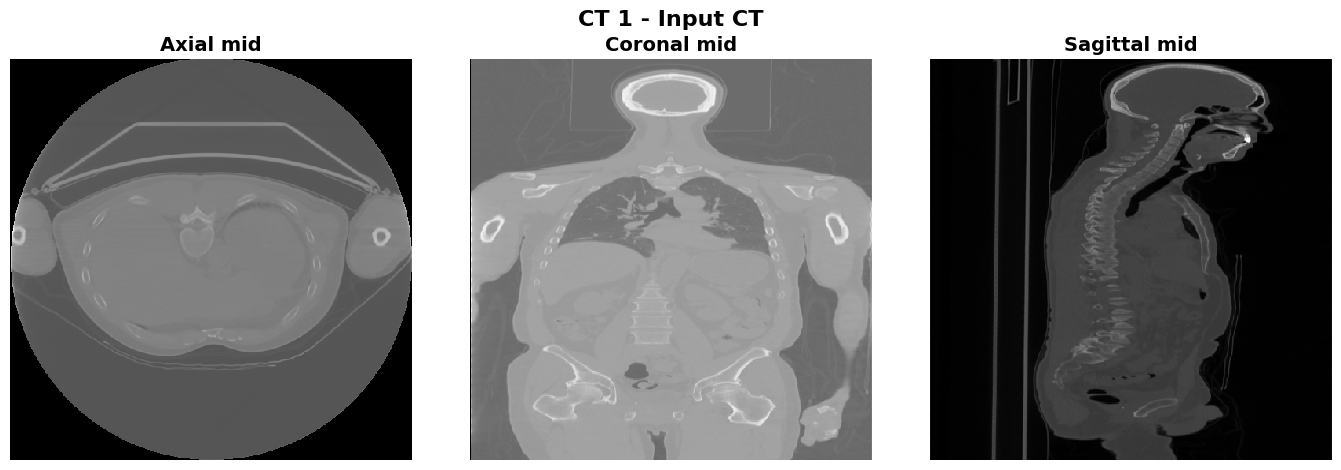

CT 2  shape=(z=335, y=512, x=512)  spacing=(0.98, 0.98, 3.27) mm


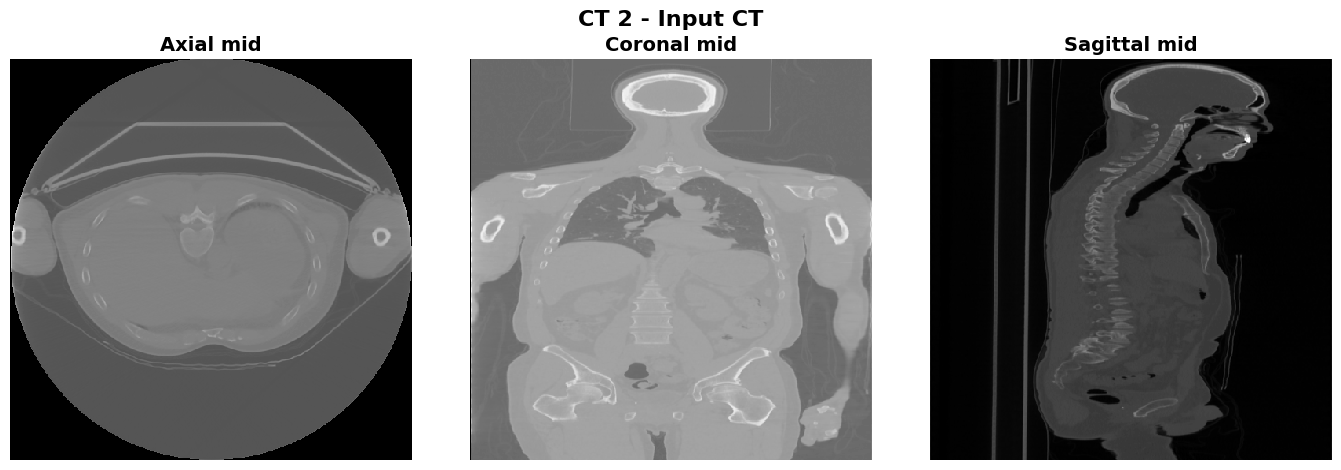

In [62]:
for i, folder in enumerate(OUT_FOLDERS):
    ct_path = os.path.join(folder, 'digital_twin', 'ct.nii.gz')
    if not os.path.exists(ct_path):
        print(f'CT {i+1}: ct.nii.gz not found')
        continue

    img = sitk.ReadImage(ct_path)
    arr = sitk.GetArrayFromImage(img)[::-1]   # z,y,x display order, head-up
    sp  = img.GetSpacing()                    # x,y,z in mm
    z, y, x = arr.shape
    print(f'CT {i+1}  shape=(z={z}, y={y}, x={x})  spacing=({sp[0]:.2f}, {sp[1]:.2f}, {sp[2]:.2f}) mm')

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
    fig.suptitle(f'CT {i+1} - Input CT')
    cmap = plot_spec('ct', 'cmap', 'gray')

    views = [
        ('Axial mid',    arr[z//2, :, :], 'axial'),
        ('Coronal mid',  arr[:, y//2, :], 'coronal'),
        ('Sagittal mid', arr[:, :, x//2], 'sagittal'),
    ]
    for ax, (title, sl, view) in zip(axes, views):
        plot_image(ax, sl, sp=sp, view=view, cmap=cmap, title=title, interpolation='nearest')
    finish_plot(fig, f'ct_{i+1}_input_ct')


### 5b - VTT Segmentation

Expected output: label dictionary and three max-projection segmentation views. This is a quick spatial sanity check, not a quantitative metric.


CT 1  seg shape=(335, 512, 512)  labels={1: 'remaining_body', 2: 'kidney', 3: 'liver', 4: 'prostate', 5: 'spleen', 6: 'heart', 7: 'salivary_glands', 8: 'synthetic_lesion'}


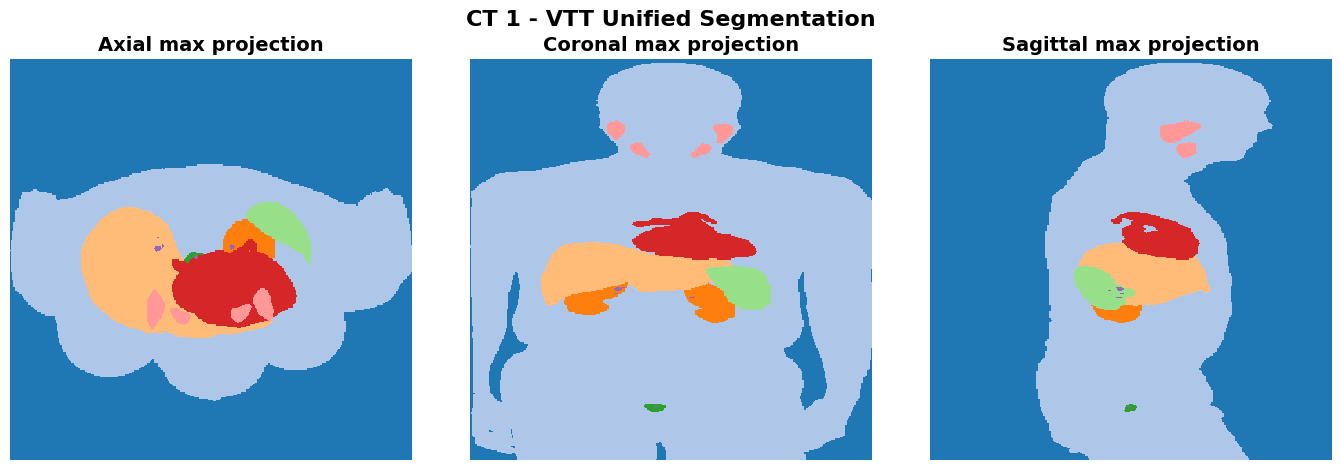

CT 2  seg shape=(335, 512, 512)  labels={1: 'remaining_body', 3: 'liver'}


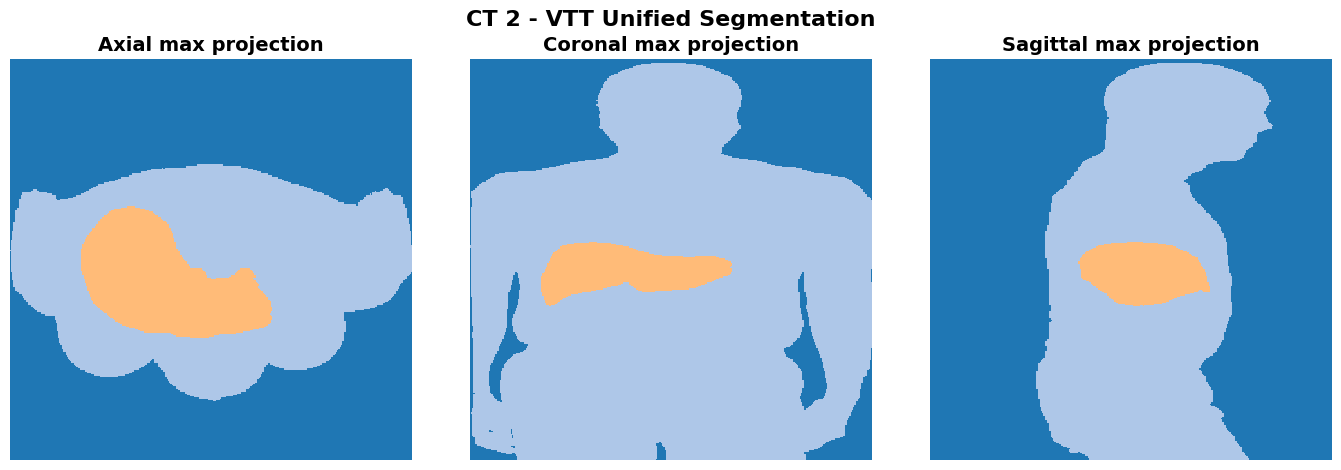

In [63]:
vtt_map_path = os.path.join(OUTPUT_ROOT, 'src', 'data', 'vtt_map.json')
label_to_roi = {}
if os.path.exists(vtt_map_path):
    vtt = load_json(vtt_map_path)
    vtt_pipe = vtt.get('VTT_Pipeline', vtt.get('TDT_Pipeline', {}))
    label_to_roi = {int(k): v.lower() for k, v in vtt_pipe.items()}

for i, folder in enumerate(OUT_FOLDERS):
    seg_path = os.path.join(folder, 'digital_twin', 'digital_twin.nii.gz')
    if not os.path.exists(seg_path):
        print(f'CT {i+1}: digital_twin.nii.gz not found')
        continue

    seg_img = sitk.ReadImage(seg_path)
    seg     = sitk.GetArrayFromImage(seg_img)[::-1]
    sp      = seg_img.GetSpacing()
    labels  = [int(v) for v in np.unique(seg) if v != 0]
    roi_names = [label_to_roi.get(l, str(l)) for l in labels]
    print(f'CT {i+1}  seg shape={seg.shape}  labels={dict(zip(labels, roi_names))}')

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
    fig.suptitle(f'CT {i+1} - VTT Unified Segmentation')
    cmap = plot_spec('segmentation', 'cmap', 'tab20')

    views = [
        ('Axial max projection',    np.max(seg, axis=0), 'axial'),
        ('Coronal max projection',  np.max(seg, axis=1), 'coronal'),
        ('Sagittal max projection', np.max(seg, axis=2), 'sagittal'),
    ]
    for ax, (title, proj, view) in zip(axes, views):
        plot_image(ax, proj, sp=sp, view=view, cmap=cmap, title=title, vmin=0, vmax=max(20, int(seg.max())), interpolation='nearest')
    finish_plot(fig, f'ct_{i+1}_segmentation')


### 5c - Synthetic Lesions

Expected output: lesion count and lesion-label projections for patients where synthetic lesions were generated; otherwise a clear "no synthetic lesions" message.


CT 1  6 lesion(s)  shape=(335, 512, 512)


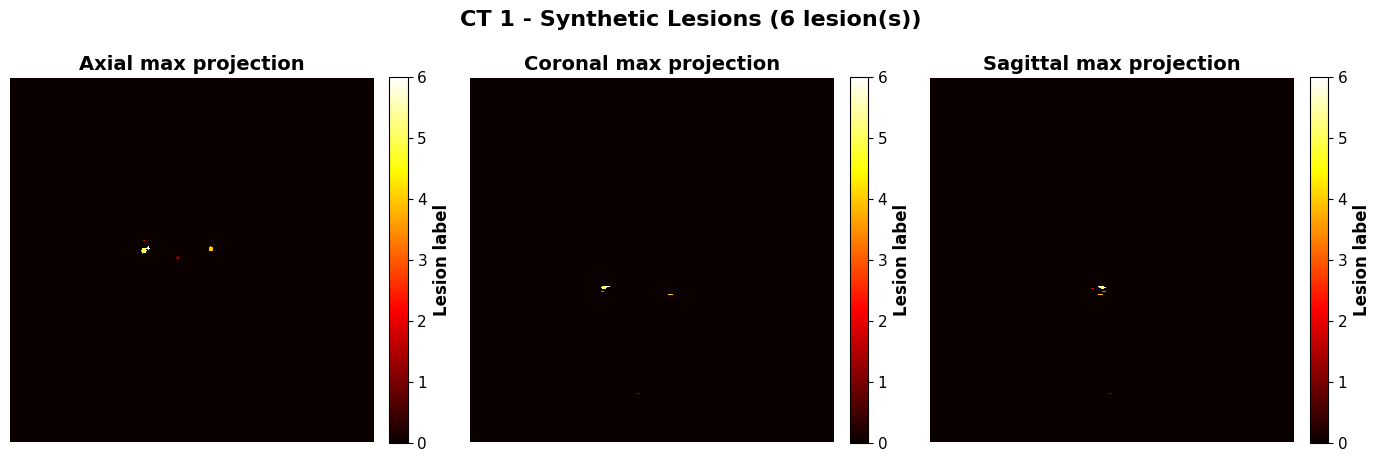

CT 2: no synthetic lesions


In [64]:
for i, folder in enumerate(OUT_FOLDERS):
    lesion_path = os.path.join(folder, 'digital_twin', 'synthetic_lesions_stage', 'synthetic_lesions_all_lesions_labels.nii.gz')
    if not os.path.exists(lesion_path):
        print(f'CT {i+1}: no synthetic lesions')
        continue

    img = sitk.ReadImage(lesion_path)
    arr = sitk.GetArrayFromImage(img)[::-1]
    sp = img.GetSpacing()
    n_lesions = int(np.max(arr))
    print(f'CT {i+1}  {n_lesions} lesion(s)  shape={arr.shape}')

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
    fig.suptitle(f'CT {i+1} - Synthetic Lesions ({n_lesions} lesion(s))')
    cmap = plot_spec('lesions', 'cmap', 'hot')

    views = [
        ('Axial max projection',    np.max(arr, axis=0), 'axial'),
        ('Coronal max projection',  np.max(arr, axis=1), 'coronal'),
        ('Sagittal max projection', np.max(arr, axis=2), 'sagittal'),
    ]
    for ax, (title, proj, view) in zip(axes, views):
        im = plot_image(ax, proj, sp=sp, view=view, cmap=cmap, title=title, interpolation='nearest')
        add_colorbar(fig, ax, im, label='Lesion label')
    finish_plot(fig, f'ct_{i+1}_synthetic_lesions')


### 5d - PBPK TACs

Expected output: PBPK metadata summary and one TAC subplot per saved ROI. The NPZ time array is in minutes and is converted to hours with `/ 60.0`.


CT 1: 8 TACs | points=95,717 | dt=1 min | range=0.00-1595.28 hr (66.47 days)
  model=PSMA isotope=lu177 half_life=159.53 hr
  SPECT frame times: ['1.00h', '2.00h', '24.00h', '48.00h']


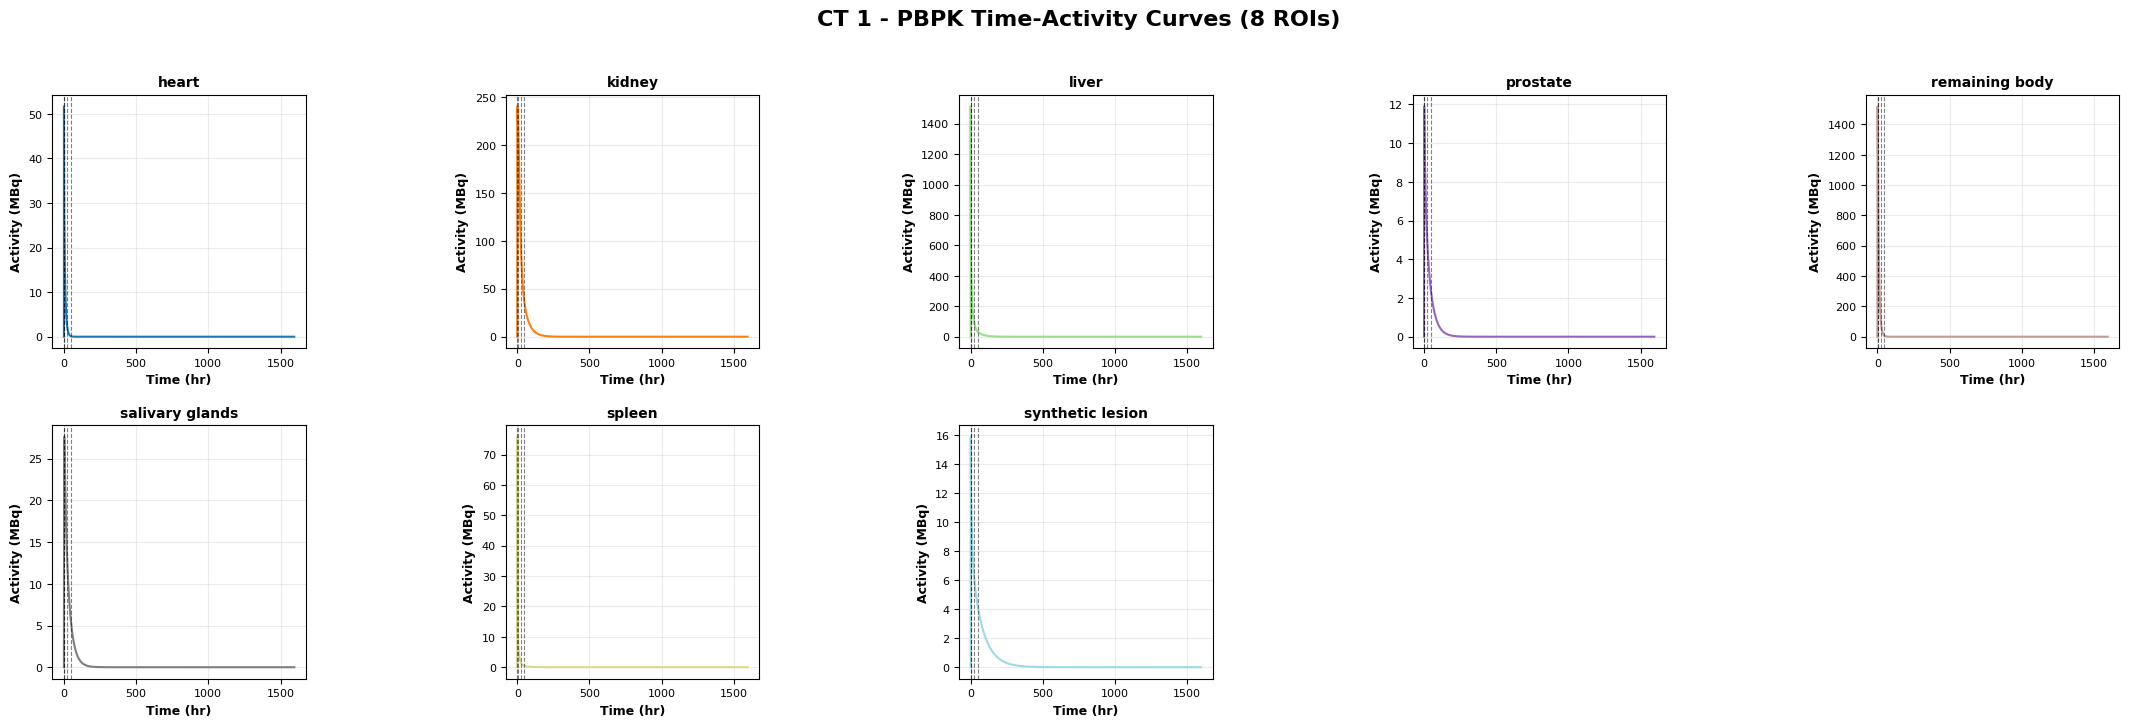

CT 2: 2 TACs | points=95,717 | dt=1 min | range=0.00-1595.28 hr (66.47 days)
  model=PSMA isotope=lu177 half_life=159.53 hr
  SPECT frame times: ['1.00h', '2.00h', '24.00h', '48.00h']


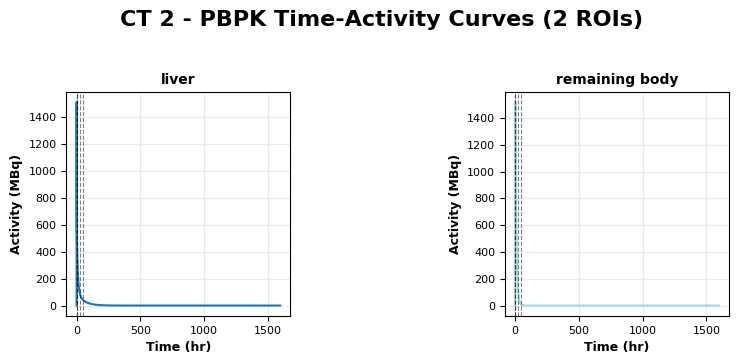

In [65]:
pbpk_store = {}   # {i: {'time_hr': arr, roi: arr_MBq, ...}}
pbpk_meta_store = {}

for i, folder in enumerate(OUT_FOLDERS):
    stage_dir = os.path.join(folder, 'digital_twin', 'pbpk_tac_stage')
    npz_path = os.path.join(stage_dir, 'pbpk_tacs.npz')
    json_path = os.path.join(stage_dir, 'pbpk_tacs.json')
    if not os.path.exists(npz_path):
        print(f'CT {i+1}: pbpk_tacs.npz not found')
        continue

    data = np.load(npz_path, allow_pickle=True)
    time_min = data['time'].astype(float)
    time_hr = time_min / 60.0
    tac_rois = {k.replace('tac_', ''): data[k].astype(float) for k in data.files if k.startswith('tac_')}
    pbpk_store[i] = {'time_hr': time_hr, **tac_rois}

    meta = load_json(json_path) if os.path.exists(json_path) else {}
    pbpk_meta_store[i] = meta
    dt_min = float(np.median(np.diff(time_min))) if time_min.size > 1 else np.nan
    print(f"CT {i+1}: {len(tac_rois)} TACs | points={len(time_min):,} | dt={dt_min:.3g} min | "
          f"range={time_hr[0]:.2f}-{time_hr[-1]:.2f} hr ({time_hr[-1]/24:.2f} days)")
    if meta:
        print(f"  model={meta.get('model_type', '-')} isotope={meta.get('isotope', '-')} "
              f"half_life={meta.get('half_life_min', np.nan)/60:.2f} hr")

    frame_hr = []
    if i in configs:
        ft = sorted(configs[i].get('phase_3', {}).get('spect_postprocess_stage', {}).get('FrameStartTimes', []))
        frame_hr = [t / 60.0 for t in ft]

    plot_rois = sorted(tac_rois.keys())
    fig, axes, nrows, ncols = make_grid(plot_rois and len(plot_rois) or 0, max_cols=5, panel_w=4.6, panel_h=3.6)
    if fig is None:
        continue
    fig.suptitle(f'CT {i+1} - PBPK Time-Activity Curves ({len(plot_rois)} ROIs)', y=1.01)
    colors = plt.get_cmap(plot_spec('pbpk', 'line_cmap', 'tab20'))(np.linspace(0, 1, len(plot_rois)))

    for j, (roi, col) in enumerate(zip(plot_rois, colors)):
        ax = axes[j // ncols][j % ncols]
        ax.plot(time_hr, tac_rois[roi], lw=1.5, color=col)
        for ft in frame_hr:
            ax.axvline(ft, color='k', lw=0.8, ls='--', alpha=0.5)
        if PBPK_XLIM_HR is not None:
            ax.set_xlim(*PBPK_XLIM_HR)
        ax.set_yscale(PBPK_Y_SCALE)
        ax.set_title(roi.replace('_', ' '), fontsize=10)
        ax.set_xlabel('Time (hr)', fontsize=9)
        ax.set_ylabel('Activity (MBq)', fontsize=9)
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=8)
        if FORCE_SQUARE_PANELS:
            ax.set_box_aspect(1)

    for j in range(len(plot_rois), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)

    if frame_hr:
        print(f"  SPECT frame times: {[f'{t:.2f}h' for t in frame_hr]}")
    finish_plot(fig, f'ct_{i+1}_pbpk_tacs')


## 6 - Phase 2: Simulation Outputs

Expected plots: SIMIND attenuation/activity maps and OpenGATE dose maps if those stages were run.


### 6a - SIMIND Attenuation and Activity Maps

Expected output: SIMIND geometry text plus square coronal max-projection panels for the attenuation map and each ROI activity map.


CT 1  prefix=simind  ROIs=['remaining_body', 'liver']
  scale_factor=1.0000  spacing_cm=[0.327, 0.098, 0.098]  shape=[335, 512, 512]
  pixel_width=0.098 cm  slice_width=0.327 cm


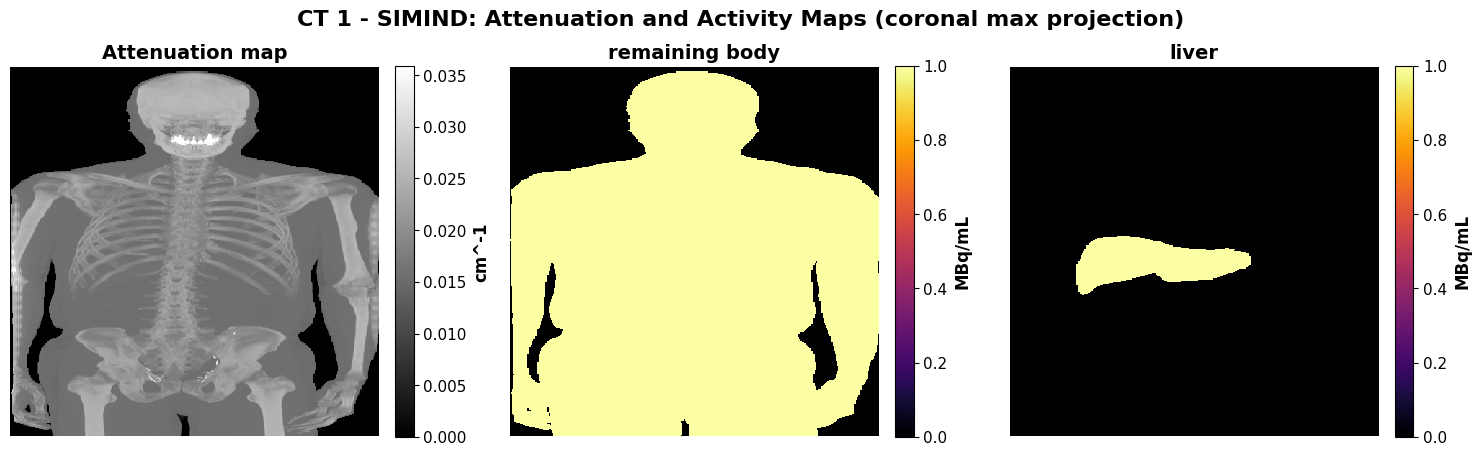

CT 2  prefix=simind  ROIs=['remaining_body', 'liver']
  scale_factor=1.0000  spacing_cm=[0.5, 0.25, 0.25]  shape=[219, 200, 200]
  pixel_width=0.250 cm  slice_width=0.500 cm


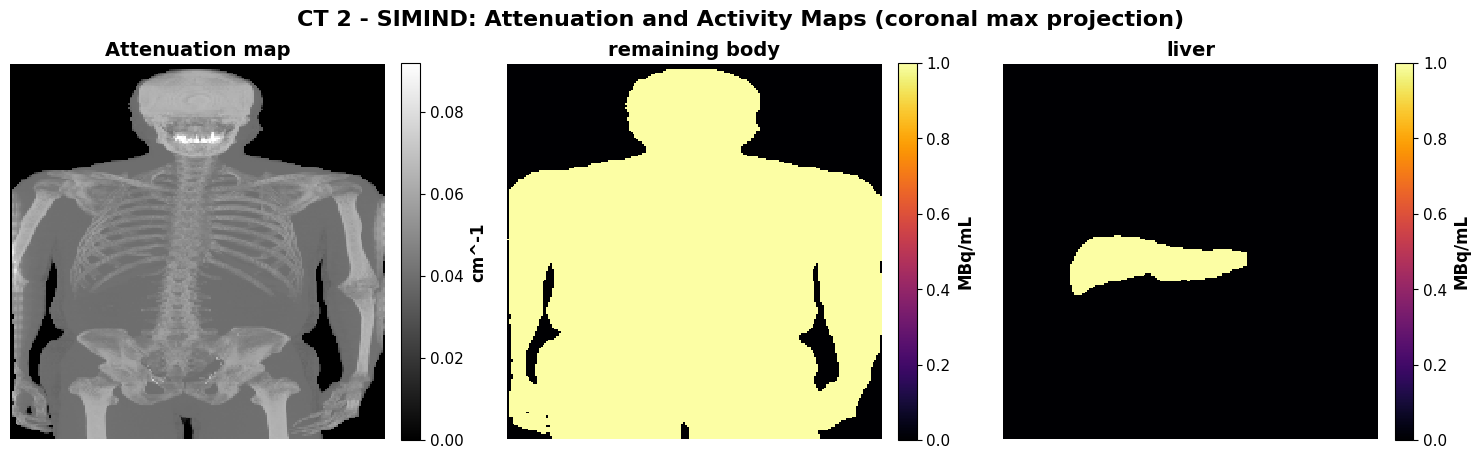

In [66]:
simind_meta_store = {}

for i, folder in enumerate(OUT_FOLDERS):
    meta_path = os.path.join(folder, 'pipeline_metadata', 'simind_simulation_stage.json')
    if not os.path.exists(meta_path):
        print(f'CT {i+1}: SIMIND metadata not found')
        continue

    m = load_json(meta_path)
    simind_meta_store[i] = m

    prefix = m.get('file_prefix', 'simind')
    roi_list = m.get('roi_list', [])
    scale = m.get('scale_factor', 1.0)
    geom = m.get('geometry', {})
    prep_dir = m.get('preprocess_dir', '')
    work_dir = m.get('work_dir', '')
    spacing = m.get('arr_px_spacing_cm', [0, 0, 0])
    shape_new = [int(v) for v in m.get('arr_shape_new', [0, 0, 0])]
    z_dim, y_dim, x_dim = shape_new if len(shape_new) == 3 else (0, 0, 0)

    print(f'CT {i+1}  prefix={prefix}  ROIs={roi_list}')
    print(f"  scale_factor={scale:.4f}  spacing_cm={[round(s, 3) for s in spacing]}  shape={shape_new}")
    print(f"  pixel_width={geom.get('input_pixel_width', 0):.3f} cm  "
          f"slice_width={geom.get('input_slice_width', 0):.3f} cm")

    atn_flat = None
    for search_dir in [prep_dir, work_dir]:
        atn_p = os.path.join(search_dir, f'{prefix}_atn_av.bin')
        if os.path.exists(atn_p):
            atn_flat = np.fromfile(atn_p, dtype=np.float32)
            break

    act_maps = {}
    act_paths = m.get('binary_roi_act_map_paths', {})
    for roi in roi_list:
        p = act_paths.get(roi, os.path.join(prep_dir, f'{prefix}_{roi}_act_av.bin'))
        if os.path.exists(p) and z_dim and y_dim and x_dim:
            flat = np.fromfile(p, dtype=np.float32)
            if flat.size == z_dim * y_dim * x_dim:
                act_maps[roi] = flat.reshape(z_dim, y_dim, x_dim)[::-1]
            else:
                print(f'  {roi}: binary size mismatch, expected {z_dim*y_dim*x_dim:,}, got {flat.size:,}')

    n_plots = (1 if atn_flat is not None else 0) + len(act_maps)
    if n_plots == 0:
        print('  No SIMIND binary maps found')
        continue

    fig, axes, nrows, ncols = make_grid(n_plots, max_cols=4, panel_w=5.0, panel_h=4.6)
    fig.suptitle(f'CT {i+1} - SIMIND: Attenuation and Activity Maps (coronal max projection)')
    idx = 0

    if atn_flat is not None and z_dim and y_dim and x_dim and atn_flat.size == z_dim * y_dim * x_dim:
        atn = atn_flat.reshape(z_dim, y_dim, x_dim)[::-1]
        ax = axes[idx // ncols][idx % ncols]
        im = plot_image(ax, np.max(atn, axis=1), cmap=plot_spec('simind', 'atn_cmap', 'gray'), title='Attenuation map')
        add_colorbar(fig, ax, im, label='cm^-1')
        idx += 1

    for roi, arr in act_maps.items():
        ax = axes[idx // ncols][idx % ncols]
        im = plot_image(ax, np.max(arr, axis=1), cmap=plot_spec('simind', 'activity_cmap', 'inferno'), title=roi.replace('_', ' '))
        add_colorbar(fig, ax, im, label='MBq/mL')
        idx += 1

    for j in range(idx, nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    finish_plot(fig, f'ct_{i+1}_simind_maps')


### 6b - OpenGATE Dose Maps

Expected output: one square panel per ROI dose map plus the summed dose map if available. Units are Gy/decay at this stage.


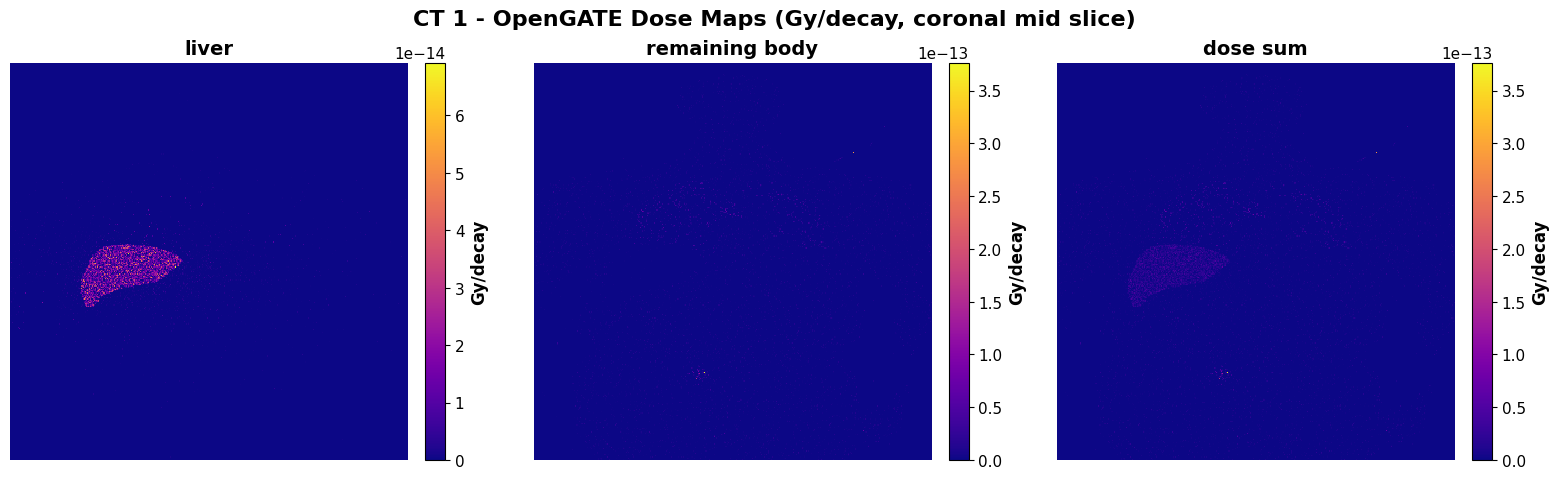

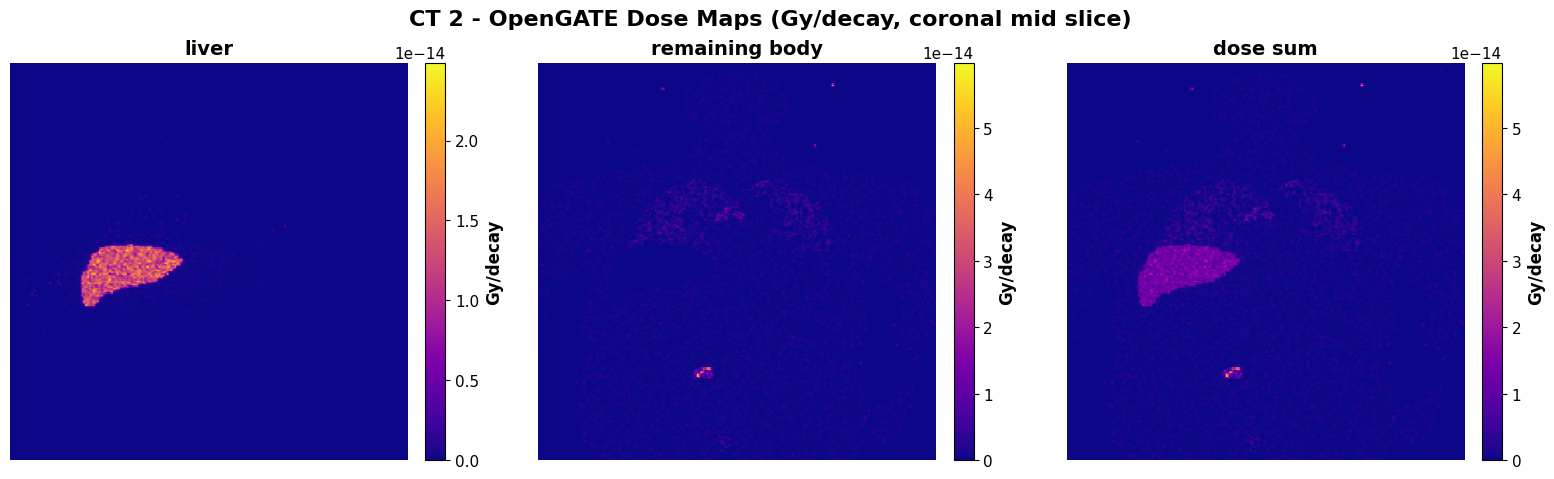

In [67]:
for i, folder in enumerate(OUT_FOLDERS):
    og_cfg = configs.get(i, {}).get('phase_2', {}).get('opengate_stage', {})
    prefix = og_cfg.get('file_prefix', 'opengate_simulation')
    og_dir = os.path.join(folder, 'simulations', og_cfg.get('sub_dir_name', 'opengate_simulation'))
    og_work = os.path.join(og_dir, 'work_dir')

    tag = prefix + '_dose_'
    dose_roi_files = [f for f in list_files(og_dir, '.nii.gz') if os.path.basename(f).startswith(tag)]
    if not dose_roi_files:
        dose_roi_files = [f for f in list_files(og_work, '.nii.gz') if os.path.basename(f).startswith(tag)]

    dose_sum_path = None
    for candidate in [
        os.path.join(folder, 'simulations', prefix + '_dose_sum.nii.gz'),
        os.path.join(og_dir, prefix + '_dose_sum.nii.gz'),
        os.path.join(og_work, prefix + '_dose_sum.nii.gz'),
    ]:
        if os.path.exists(candidate):
            dose_sum_path = candidate
            break

    all_dose = []
    for p in dose_roi_files:
        s = stem(p)
        if s.endswith('_dose_sum'):
            continue
        roi_label = s[len(tag):] if s.startswith(tag) else s
        all_dose.append((roi_label, p))
    if dose_sum_path:
        all_dose.append(('dose sum', dose_sum_path))

    if not all_dose:
        print(f'CT {i+1}: no OpenGATE dose maps found (--dosimetry may not have run)')
        continue

    fig, axes, nrows, ncols = make_grid(len(all_dose), max_cols=4, panel_w=5.3, panel_h=4.8)
    fig.suptitle(f'CT {i+1} - OpenGATE Dose Maps (Gy/decay, coronal mid slice)')
    cmap = plot_spec('opengate', 'cmap', 'plasma')

    for j, (label, path) in enumerate(all_dose):
        ax = axes[j // ncols][j % ncols]
        img = sitk.ReadImage(path)
        arr = sitk.GetArrayFromImage(img)[::-1]
        sp = img.GetSpacing()
        z, y, x = arr.shape
        im = plot_image(ax, arr[:, y // 2, :], sp=sp, view='coronal', cmap=cmap, title=label.replace('_', ' '))
        add_colorbar(fig, ax, im, label='Gy/decay')

    for j in range(len(all_dose), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    finish_plot(fig, f'ct_{i+1}_opengate_dose_maps')


## 7 - Phase 3: Post-processing Outputs

Expected plots: reconstructed SPECT frames, per-ROI activity maps, total dose maps, and dose integration summaries.


### 7a - Reconstructed SPECT

Expected output: three views per selected frame. Use `SPECT_FRAME_MODE='last'` in setup if you only want the final frame.


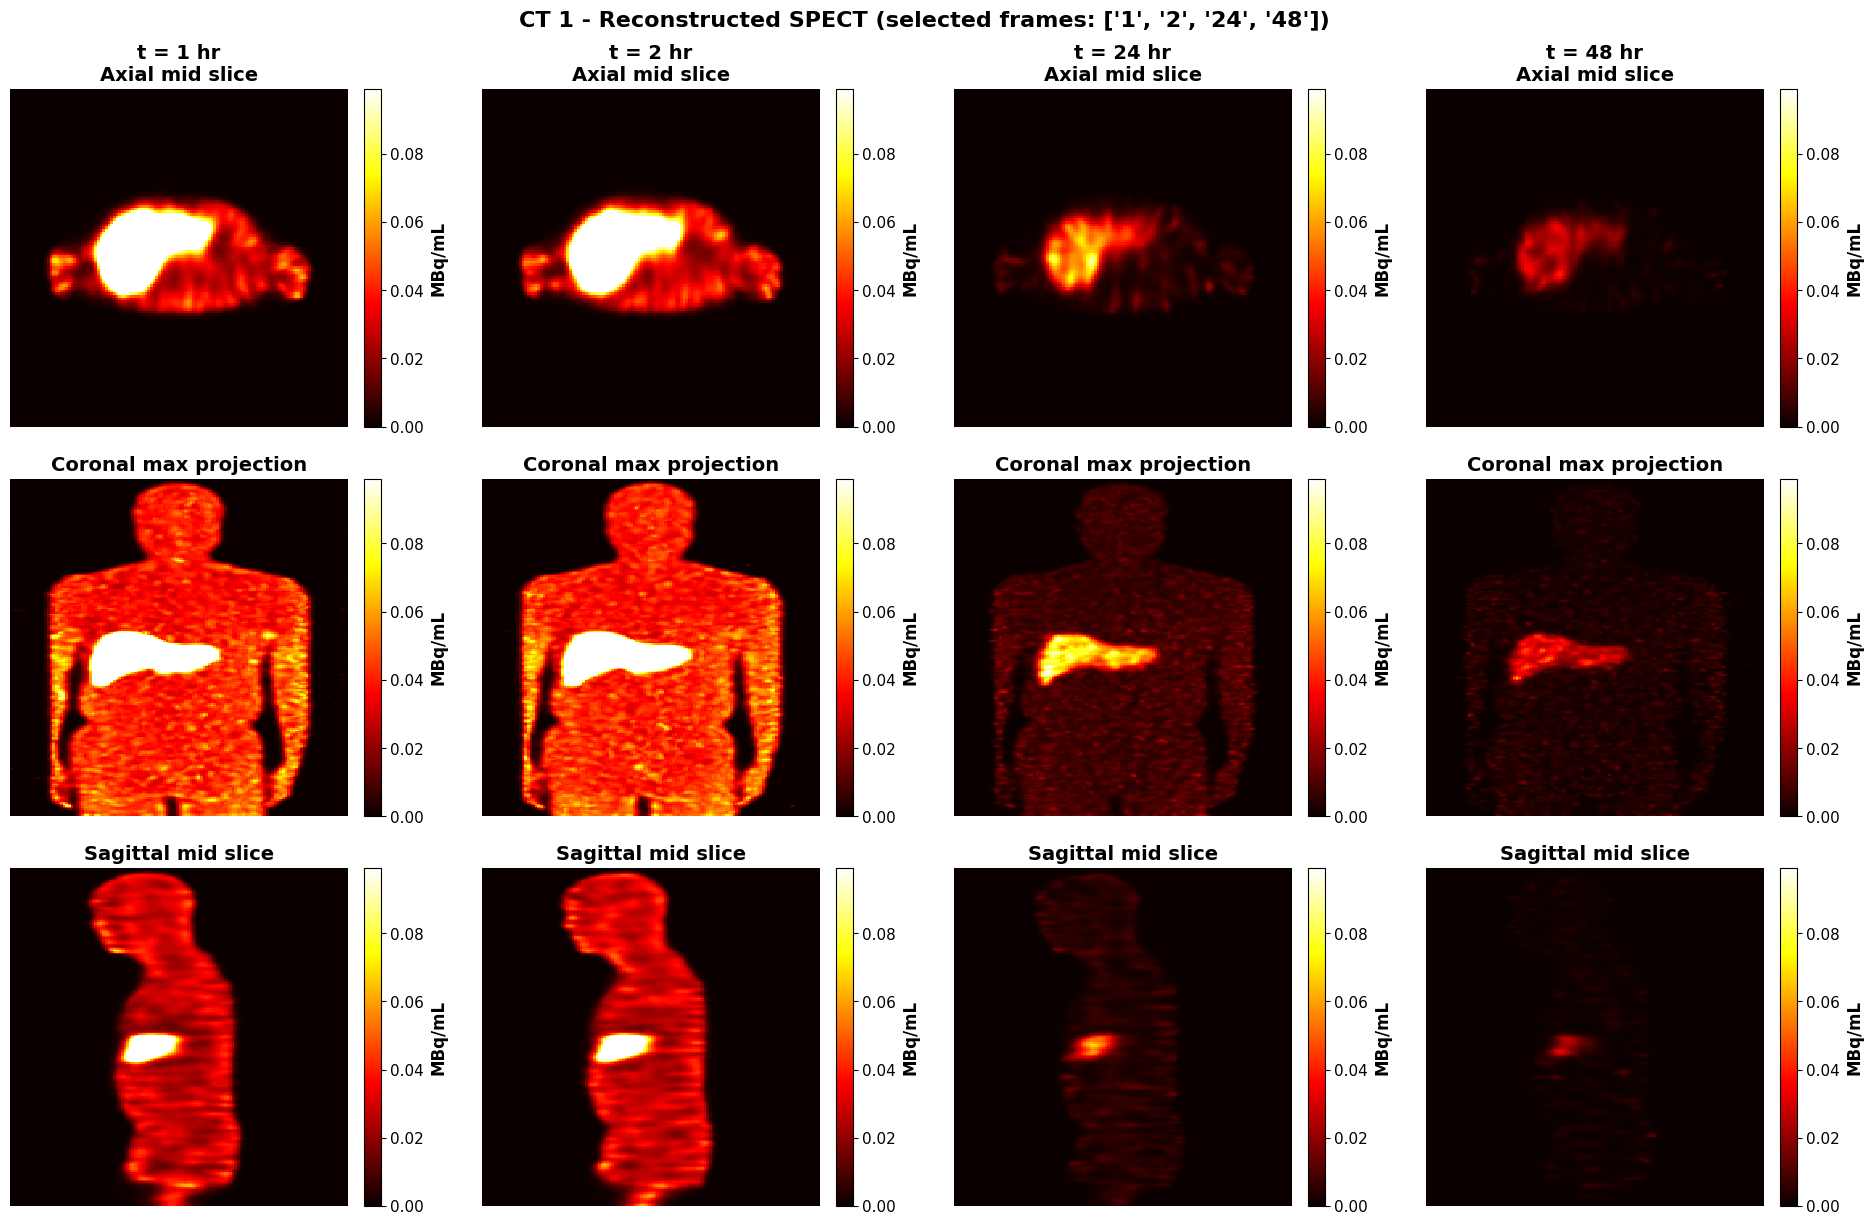

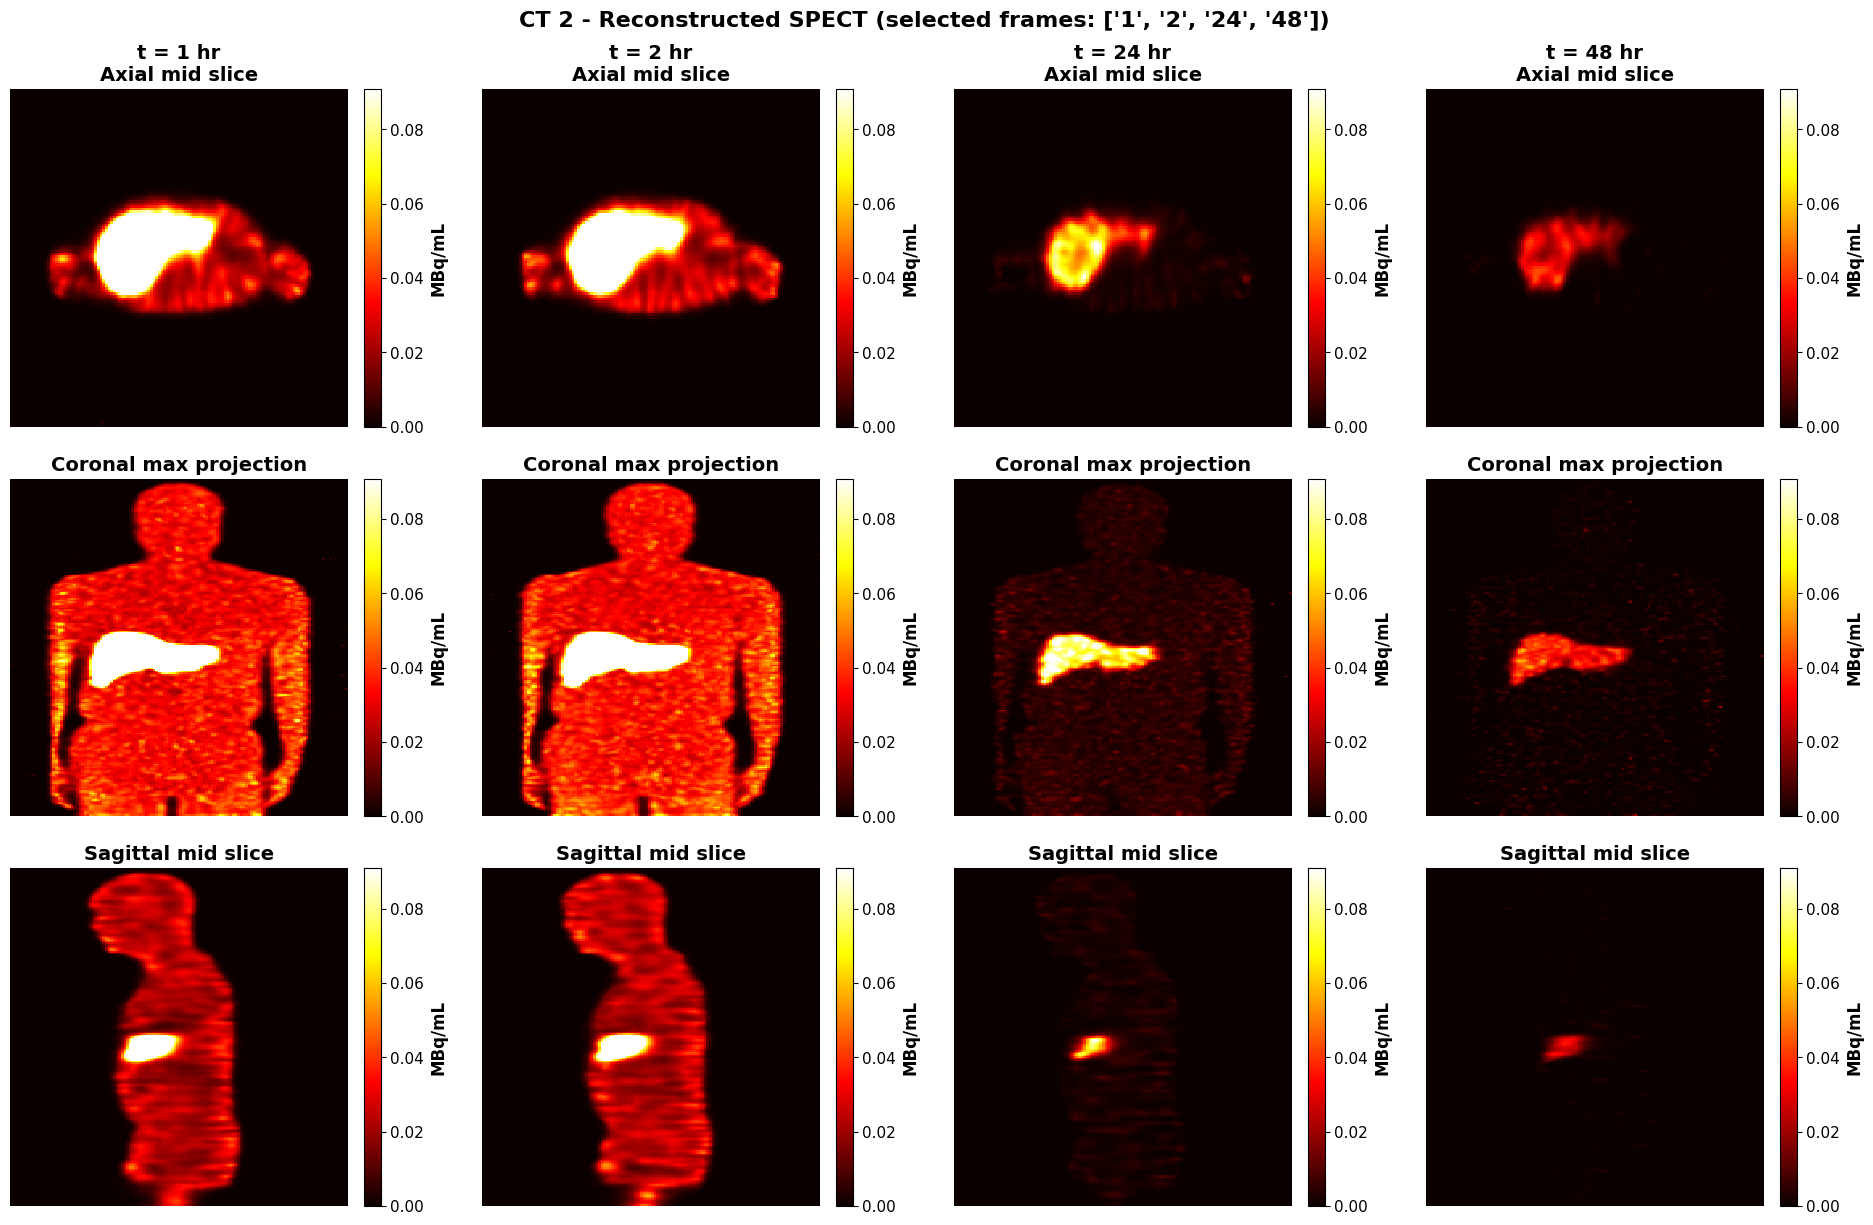

In [68]:
recon_paths_store = {}

for i, folder in enumerate(OUT_FOLDERS):
    pp_dir = os.path.join(folder, 'post_processing')
    recons = [
        os.path.join(pp_dir, f) for f in sorted(os.listdir(pp_dir))
        if f.startswith('reconstructed_SPECT_') and f.endswith('.nii.gz')
    ] if os.path.isdir(pp_dir) else []

    if not recons:
        print(f'CT {i+1}: no reconstructed SPECT (--spect --postprocess may not have run)')
        continue

    frame_map = {}
    for p in recons:
        label = os.path.basename(p).replace('reconstructed_SPECT_', '').replace('.nii.gz', '')
        frame_map[label] = p
    recon_paths_store[i] = frame_map

    frame_labels = select_frame_labels(frame_map.keys(), SPECT_FRAME_MODE, SPECT_SELECTED_FRAMES)
    if not frame_labels:
        print(f'CT {i+1}: no SPECT frames selected')
        continue

    arrs = {}
    vmax = 0.0
    for label in frame_labels:
        img = sitk.ReadImage(frame_map[label])
        arr = sitk.GetArrayFromImage(img)[::-1]
        sp = img.GetSpacing()
        arrs[label] = (arr, sp)
        pos = arr[arr > 0]
        if pos.size:
            vmax = max(vmax, float(np.percentile(pos, plot_spec('spect', 'percentile', 99.5))))
    vmax = vmax if SPECT_SHARED_SCALE and vmax > 0 else None

    ncols = len(frame_labels)
    fig, axes = plt.subplots(3, ncols, figsize=(4.8 * ncols, 12.5), squeeze=False)
    fig.suptitle(f'CT {i+1} - Reconstructed SPECT (selected frames: {frame_labels})')
    cmap = plot_spec('spect', 'cmap', 'hot')

    row_labels = ['Axial mid slice', 'Coronal max projection', 'Sagittal mid slice']
    for j, label in enumerate(frame_labels):
        arr, sp = arrs[label]
        z, y, x = arr.shape
        views = [
            (arr[z//2, :, :],     'axial'),
            (np.max(arr, axis=1), 'coronal'),
            (arr[:, :, x//2],     'sagittal'),
        ]
        for row, (sl, view) in enumerate(views):
            title = f't = {label} hr\n{row_labels[row]}' if row == 0 else row_labels[row]
            im = plot_image(axes[row][j], sl, sp=sp, view=view, cmap=cmap, title=title, vmin=0, vmax=vmax)
            add_colorbar(fig, axes[row][j], im, label='MBq/mL')

    finish_plot(fig, f'ct_{i+1}_reconstructed_spect')


### 7b - Per-ROI Activity Maps

Expected output: one square coronal-mid panel per postprocessed ROI activity map.


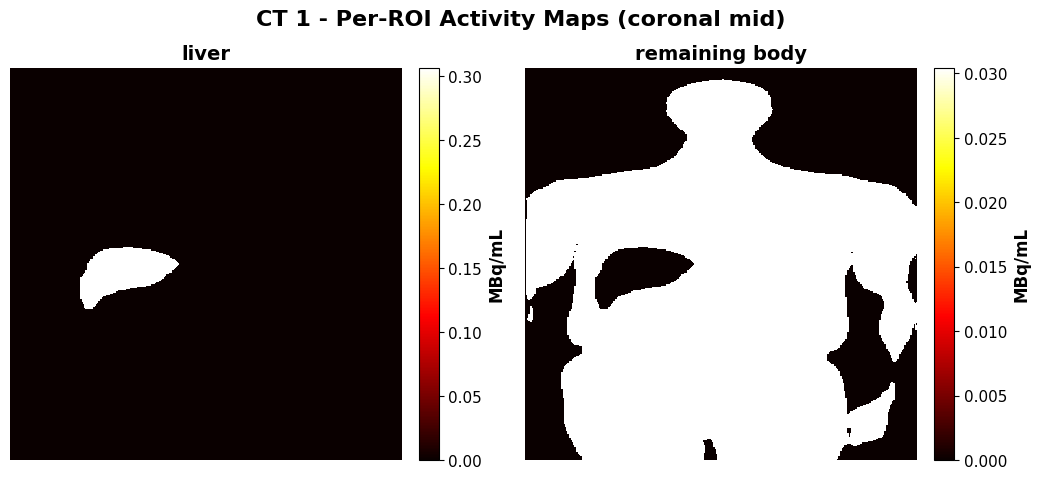

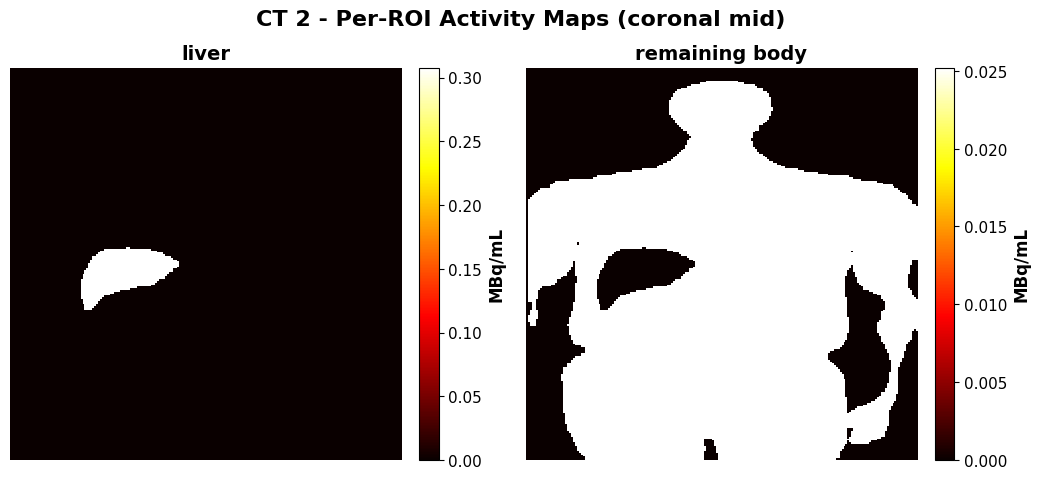

In [69]:
for i, folder in enumerate(OUT_FOLDERS):
    work_dir = os.path.join(folder, 'post_processing', 'spect_postprocess', 'work_dir')
    act_files = list_files(work_dir, '_act_av.nii.gz')
    if not act_files:
        print(f'CT {i+1}: no per-ROI activity maps')
        continue

    sp_prefix = configs.get(i, {}).get('phase_3', {}).get('spect_postprocess_stage', {}).get('file_prefix', 'spect_postprocess')
    labels = []
    for p in act_files:
        s = stem(p).replace('_act_av', '')
        labels.append(s[len(sp_prefix)+1:] if s.startswith(sp_prefix + '_') else s)

    fig, axes, nrows, ncols = make_grid(len(act_files), max_cols=4, panel_w=5.3, panel_h=4.8)
    fig.suptitle(f'CT {i+1} - Per-ROI Activity Maps (coronal mid)')
    cmap = plot_spec('activity', 'cmap', 'hot')

    for j, (path, label) in enumerate(zip(act_files, labels)):
        ax = axes[j // ncols][j % ncols]
        img = sitk.ReadImage(path)
        arr = sitk.GetArrayFromImage(img)[::-1]
        sp = img.GetSpacing()
        z, y, x = arr.shape
        im = plot_image(ax, arr[:, y//2, :], sp=sp, view='coronal', cmap=cmap, title=label.replace('_', ' '))
        add_colorbar(fig, ax, im, label='MBq/mL')

    for j in range(len(act_files), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    finish_plot(fig, f'ct_{i+1}_roi_activity_maps')


### 7c - Total Dose Map

Expected output: total absorbed dose summary and three square anatomical views per patient.


CT 1  dose shape=(335, 512, 512)  spacing=(0.98, 0.98, 3.27) mm  max=72.29 Gy


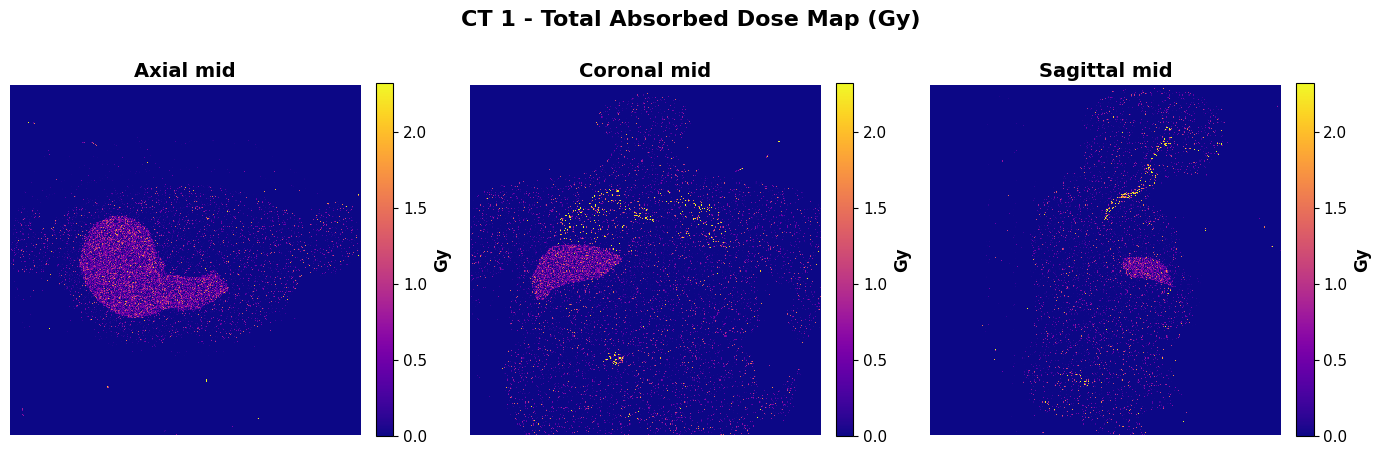

CT 2  dose shape=(335, 512, 512)  spacing=(0.98, 0.98, 3.27) mm  max=5.943 Gy


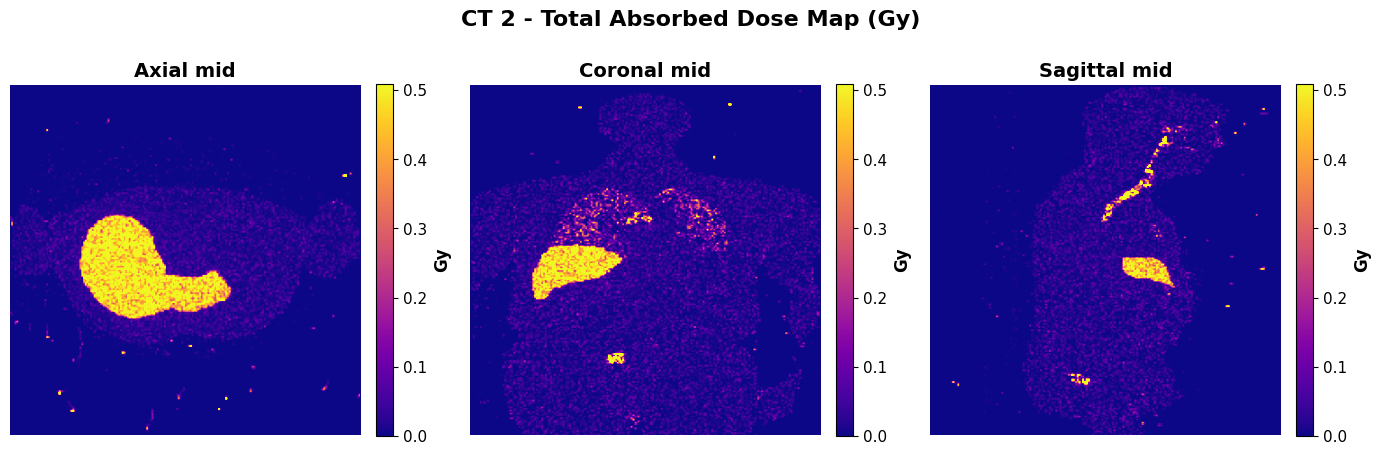

In [70]:
for i, folder in enumerate(OUT_FOLDERS):
    dose_path = os.path.join(folder, 'post_processing', 'dosemap_postprocess_total_dose.nii.gz')
    if not os.path.exists(dose_path):
        print(f'CT {i+1}: total dose map not found (--dosimetry --postprocess may not have run)')
        continue

    img = sitk.ReadImage(dose_path)
    arr = sitk.GetArrayFromImage(img)[::-1]
    sp = img.GetSpacing()
    z, y, x = arr.shape
    pos = arr[arr > 0]
    vm = float(np.percentile(pos, plot_spec('dose', 'percentile', 99.0))) if pos.size else float(np.max(arr))
    print(f'CT {i+1}  dose shape={arr.shape}  spacing={tuple(round(s,2) for s in sp)} mm  max={np.max(arr):.4g} Gy')

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
    fig.suptitle(f'CT {i+1} - Total Absorbed Dose Map (Gy)')
    cmap = plot_spec('dose', 'cmap', 'plasma')

    views = [
        ('Axial mid',    arr[z//2, :, :],  'axial'),
        ('Coronal mid',  arr[:, y//2, :],  'coronal'),
        ('Sagittal mid', arr[:, :, x//2], 'sagittal'),
    ]
    for ax, (title, sl, view) in zip(axes, views):
        im = plot_image(ax, sl, sp=sp, view=view, cmap=cmap, title=title, vmin=0, vmax=vm)
        add_colorbar(fig, ax, im, label='Gy')
    finish_plot(fig, f'ct_{i+1}_total_dose')


### 7d - Dose Integration Summary

Expected output: integration range and cumulated activity per ROI from dose postprocess metadata. This is useful for checking whether dose used the full PBPK horizon.



CT 1: dose integration range = [0.0, 1595.28] hr ([0.0, 66.47] days)
  ROI                   dose-stage CA direct PBPK CA  folded/additional
  liver                      32.706e12       32.706e12            0.000e12
  remaining_body             88.009e12       54.138e12           33.871e12
  inferred remaining_body folded-from PBPK ROIs:
    heart                       1.127e12 decays
    kidney                     25.379e12 decays
    prostate                    1.267e12 decays
    salivary_glands             3.059e12 decays
    spleen                      0.679e12 decays
    synthetic_lesion            2.360e12 decays


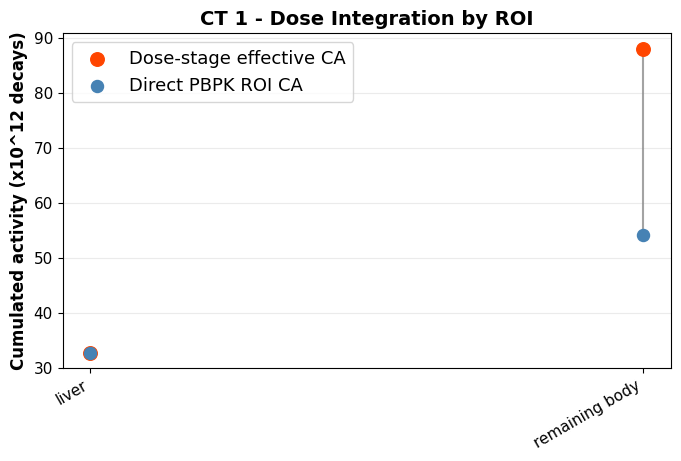


CT 2: dose integration range = [0.0, 1595.28] hr ([0.0, 66.47] days)
  ROI                   dose-stage CA direct PBPK CA  folded/additional
  liver                      36.994e12       36.994e12            0.000e12
  remaining_body             54.061e12       54.061e12           -0.000e12


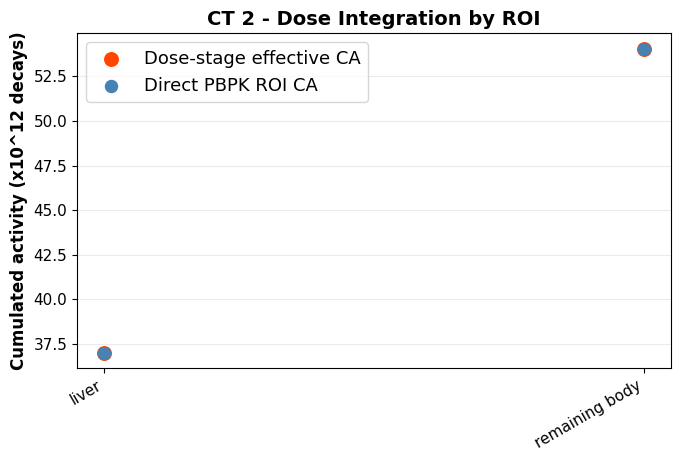

In [71]:
dose_summary_store = {}


def pbpk_decays_for_roi(patient_idx, roi):
    if patient_idx not in pbpk_store or roi not in pbpk_store[patient_idx]:
        return np.nan
    t_min = np.asarray(pbpk_store[patient_idx]['time_hr'], dtype=float) * 60.0
    y_mbq = np.asarray(pbpk_store[patient_idx][roi], dtype=float)
    return float(np.trapezoid(y_mbq, t_min) * 60.0 * 1e6)


for i, folder in enumerate(OUT_FOLDERS):
    meta_path = os.path.join(folder, 'pipeline_metadata', 'dosemap_postprocess_stage.json')
    if not os.path.exists(meta_path):
        print(f'CT {i+1}: dose postprocess metadata not found')
        continue

    m = load_json(meta_path)
    dose_summary_store[i] = m
    decays = m.get('cumulated_activities_per_roi_decays', {})
    range_hr = m.get('integration_range_hr', [])
    range_days = m.get('integration_range_days', [])
    dose_inputs = m.get('dose_input_paths', {})
    simulated_rois = set(dose_inputs.keys()) - {'remaining_body'}

    print(f"\nCT {i+1}: dose integration range = {range_hr} hr ({range_days} days)")
    if not decays:
        print('  No cumulated activity entries found')
        continue

    # The dose stage may fold PBPK ROIs that were not simulated as separate sources
    # into remaining_body. This table separates the raw PBPK TAC integral from the
    # effective dose-weighting value written in metadata.
    print(f"  {'ROI':20s} {'dose-stage CA':>14s} {'direct PBPK CA':>14s} {'folded/additional':>18s}")
    for roi, val in sorted(decays.items()):
        direct = pbpk_decays_for_roi(i, roi)
        folded = val - direct if np.isfinite(direct) else np.nan
        print(f"  {roi:20s} {val/1e12:12.3f}e12 {direct/1e12:12.3f}e12 {folded/1e12:16.3f}e12")

    folded_meta = m.get('remaining_body_folded_from_decays', {})
    if folded_meta:
        print('  remaining_body folded-from metadata:')
        for roi, val in sorted(folded_meta.items()):
            print(f'    {roi:20s} {val/1e12:12.3f}e12 decays')
    elif 'remaining_body' in decays and i in pbpk_store:
        folded_rois = [
            roi for roi in pbpk_store[i]
            if roi != 'time_hr' and roi != 'remaining_body' and roi not in simulated_rois
        ]
        folded_parts = {roi: pbpk_decays_for_roi(i, roi) for roi in folded_rois}
        folded_parts = {roi: val for roi, val in folded_parts.items() if np.isfinite(val) and abs(val) > 0}
        if folded_parts:
            print('  inferred remaining_body folded-from PBPK ROIs:')
            for roi, val in sorted(folded_parts.items()):
                print(f'    {roi:20s} {val/1e12:12.3f}e12 decays')

    rois = list(sorted(decays))
    vals = [decays[r] / 1e12 for r in rois]
    direct_vals = [pbpk_decays_for_roi(i, r) / 1e12 for r in rois]
    x = np.arange(len(rois))
    fig, ax = plt.subplots(figsize=(max(7, 1.4 * len(rois)), 4.8))
    ax.scatter(x, vals, s=95, color='orangered', label='Dose-stage effective CA', zorder=4)
    ax.scatter(x, direct_vals, s=75, color='steelblue', label='Direct PBPK ROI CA', zorder=4)
    for xi, v0, v1 in zip(x, direct_vals, vals):
        if np.isfinite(v0) and np.isfinite(v1):
            ax.plot([xi, xi], [v0, v1], color='0.55', lw=1.5, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([r.replace('_', ' ') for r in rois], rotation=30, ha='right')
    ax.set_ylabel('Cumulated activity (x10^12 decays)')
    ax.set_title(f'CT {i+1} - Dose Integration by ROI')
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend()
    finish_plot(fig, f'ct_{i+1}_dose_integration_summary')

## 8 - SPECT Comparison Setup

These cells register the segmentation to SPECT reconstruction space, extract ROI TACs from reconstructed images, and compare those TACs against PBPK. The key unit fix is here: segmentation spacing is treated as mm, reconstructed SPECT spacing as cm, and SPECT voxel volume is computed directly in mL.


### 8a - Build ROI Masks in Reconstructed SPECT Space

Expected output: recon spacing units, voxel volume, unit conversion applied to segmentation, and mask volumes per ROI.


In [72]:
def physical_center(img):
    size = np.array(img.GetSize(), dtype=float)
    sp = np.array(img.GetSpacing(), dtype=float)
    orig = np.array(img.GetOrigin(), dtype=float)
    direction = np.array(img.GetDirection(), dtype=float).reshape(3, 3)
    return orig + direction @ ((size - 1.0) / 2.0 * sp)


def set_center(img, target):
    out = sitk.Image(img)
    size = np.array(out.GetSize(), dtype=float)
    sp = np.array(out.GetSpacing(), dtype=float)
    direction = np.array(out.GetDirection(), dtype=float).reshape(3, 3)
    out.SetOrigin((target - direction @ ((size - 1.0) / 2.0 * sp)).tolist())
    return out


def resample_nn(moving, reference):
    rs = sitk.ResampleImageFilter()
    rs.SetReferenceImage(reference)
    rs.SetInterpolator(sitk.sitkNearestNeighbor)
    rs.SetDefaultPixelValue(0)
    return rs.Execute(moving)


masks_recon = {}       # {i: {roi_lower: bool mask in recon z,y,x order}}
recon_imgs_sitk = {}   # {i: {frame_label: sitk.Image}}
recon_vox_ml = {}      # {i: float}
recon_arr_ref = {}     # {i: (display_arr_zyx, spacing)}
mask_volume_store = {} # {i: {roi: {'voxels': int, 'volume_ml': float}}}

for i, folder in enumerate(OUT_FOLDERS):
    if i not in recon_paths_store:
        print(f'CT {i+1}: no recon paths - skipping comparison setup')
        continue

    seg_path = os.path.join(folder, 'digital_twin', 'digital_twin.nii.gz')
    if not os.path.exists(seg_path):
        print(f'CT {i+1}: digital_twin.nii.gz not found')
        continue

    frame_map = recon_paths_store[i]
    ref_label = sorted(frame_map.keys(), key=lambda k: float(k))[-1]
    ref_img = sitk.ReadImage(frame_map[ref_label])
    sp_recon = np.array(ref_img.GetSpacing(), dtype=float)
    recon_unit = normalize_unit(SPECT_RECON_SPACING_UNIT)
    seg_unit = normalize_unit(SEGMENTATION_SPACING_UNIT)

    recon_imgs_sitk[i] = {lbl: sitk.ReadImage(p) for lbl, p in frame_map.items()}
    recon_vox_ml[i] = voxel_volume_ml(sp_recon, recon_unit)
    recon_arr_ref[i] = (sitk.GetArrayFromImage(ref_img)[::-1], sp_recon)

    seg_img = sitk.ReadImage(seg_path)
    seg_img_recon_units = scale_img_units(seg_img, seg_unit, recon_unit)
    scale_used = unit_scale_factor(seg_unit, recon_unit)

    # Align centers before nearest-neighbor resampling. This mirrors the pipeline's center-align convention.
    seg_centered = set_center(seg_img_recon_units, physical_center(ref_img))
    seg_in_recon = resample_nn(seg_centered, ref_img)
    seg_arr = sitk.GetArrayFromImage(seg_in_recon).astype(np.int16)

    masks_recon[i] = {}
    mask_volume_store[i] = {}
    for lbl in np.unique(seg_arr):
        if lbl == 0:
            continue
        roi_name = label_to_roi.get(int(lbl), f'label_{lbl}')
        mask = (seg_arr == lbl)
        masks_recon[i][roi_name] = mask
        mask_volume_store[i][roi_name] = {
            'voxels': int(mask.sum()),
            'volume_ml': float(mask.sum() * recon_vox_ml[i]),
        }

    print(f'CT {i+1}: masks built from ref frame {ref_label} hr')
    print(f'  Recon spacing={sp_recon.round(4)} {recon_unit}; voxel volume={recon_vox_ml[i]:.6f} mL')
    print(f'  Segmentation spacing converted {seg_unit}->{recon_unit} with factor {scale_used:g}')
    for roi, stats in sorted(mask_volume_store[i].items()):
        print(f"  {roi:20s} voxels={stats['voxels']:8d} volume={stats['volume_ml']:10.3f} mL")


CT 1: masks built from ref frame 48 hr
  Recon spacing=[0.5 0.5 0.5] cm; voxel volume=0.125000 mL
  Segmentation spacing converted mm->cm with factor 0.1
  heart                voxels=    4680 volume=   585.000 mL
  kidney               voxels=    3097 volume=   387.125 mL
  liver                voxels=   13772 volume=  1721.500 mL
  prostate             voxels=      37 volume=     4.625 mL
  remaining_body       voxels=  467280 volume= 58410.000 mL
  salivary_glands      voxels=     441 volume=    55.125 mL
  spleen               voxels=    1390 volume=   173.750 mL
  synthetic_lesion     voxels=       4 volume=     0.500 mL
CT 2: masks built from ref frame 48 hr
  Recon spacing=[0.5 0.5 0.5] cm; voxel volume=0.125000 mL
  Segmentation spacing converted mm->cm with factor 0.1
  liver                voxels=   13802 volume=  1725.250 mL
  remaining_body       voxels=  476899 volume= 59612.375 mL


### 8b - Mask Overlay Sanity Check

Expected output: SPECT image with ROI contours. If these overlays look shifted, the SPECT/PBPK comparison should not be trusted until registration is fixed.


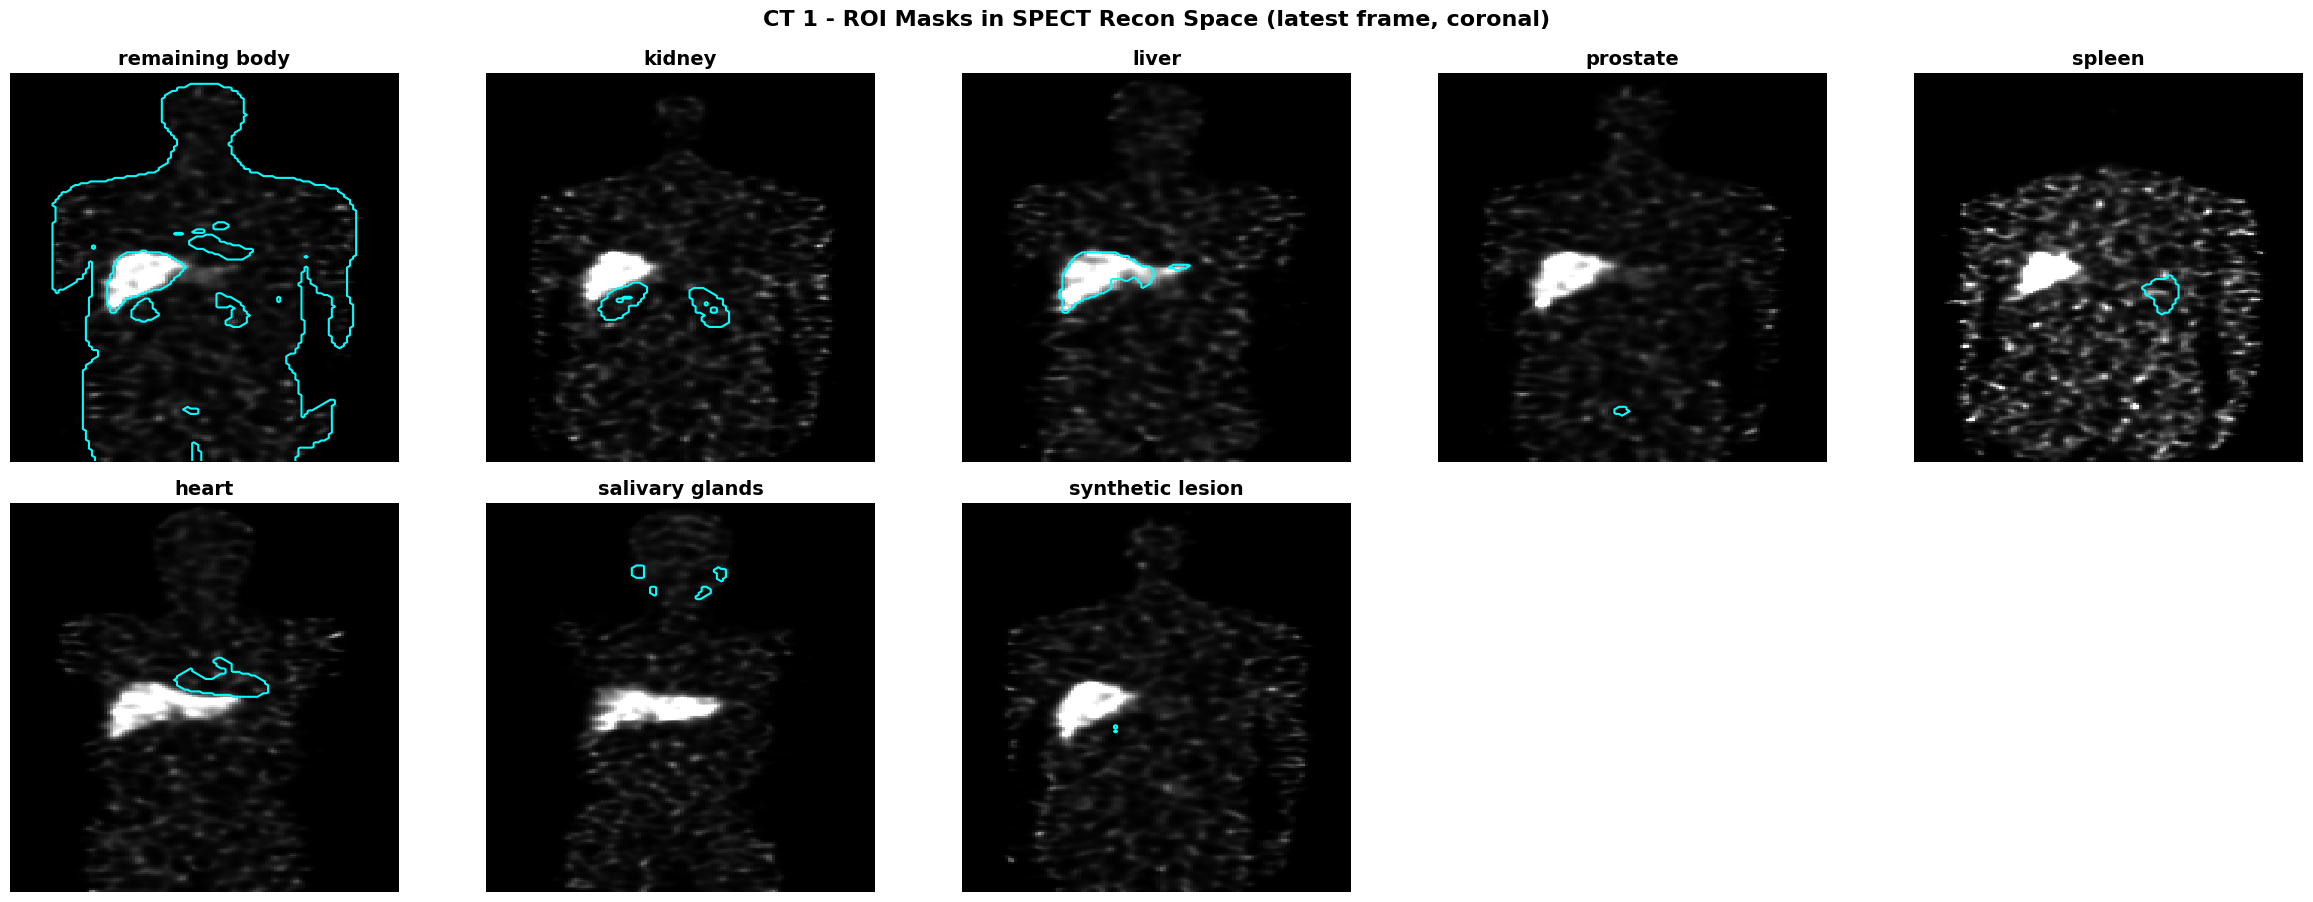

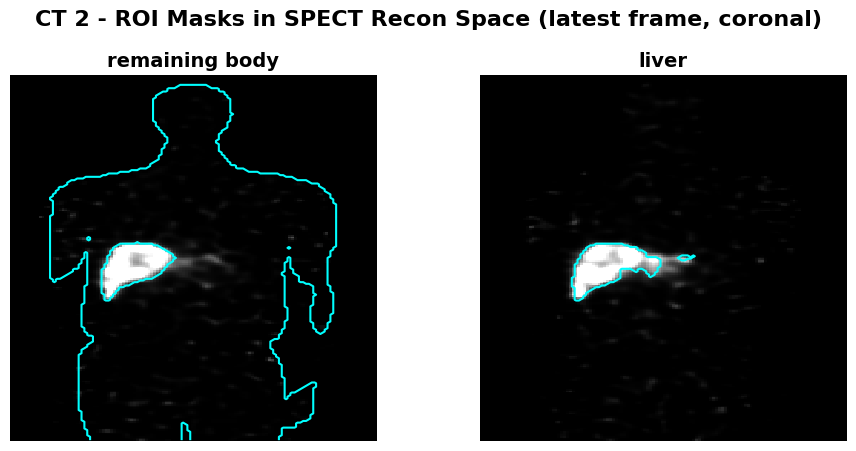

In [73]:
for i in masks_recon:
    arr_ref, sp = recon_arr_ref[i]
    rois = [r for r in masks_recon[i] if r not in ('background',)]
    if not rois:
        print(f'CT {i+1}: no masks available for overlay')
        continue

    fig, axes, nrows, ncols = make_grid(len(rois), max_cols=5, panel_w=4.8, panel_h=4.6)
    fig.suptitle(f'CT {i+1} - ROI Masks in SPECT Recon Space (latest frame, coronal)')
    image_cmap = plot_spec('mask', 'image_cmap', 'gray')
    contour_color = plot_spec('mask', 'contour_color', 'cyan')

    for j, roi in enumerate(rois):
        ax = axes[j // ncols][j % ncols]
        mask = masks_recon[i][roi][::-1]  # display orientation to match arr_ref
        pts = np.argwhere(mask)
        if pts.size == 0:
            ax.set_visible(False)
            continue
        y_sl = int(np.round(pts[:, 1].mean()))
        sl_recon = arr_ref[:, y_sl, :]
        sl_mask = mask[:, y_sl, :]
        pos = sl_recon[np.isfinite(sl_recon)]
        vmax_r = float(np.percentile(pos, 99)) if pos.size else None

        plot_image(ax, sl_recon, sp=sp, view='coronal', cmap=image_cmap, title=roi.replace('_', ' '), vmin=0, vmax=vmax_r)
        ax.contour(sl_mask.astype(np.uint8), levels=[0.5], colors=contour_color, linewidths=1.5)

    for j in range(len(rois), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    finish_plot(fig, f'ct_{i+1}_mask_overlay')


### 8c - Extract SPECT TACs

Expected output: one text line per patient listing extracted frames and ROIs. Totals are computed as `sum(MBq/mL) * voxel_mL`, so the spacing unit matters.


In [74]:
def roi_stats(arr_zyx, mask_zyx, vox_vol_ml):
    n = int(mask_zyx.sum())
    if n == 0:
        return 0.0, 0.0, 0
    mean_mbq_ml = float(np.mean(arr_zyx[mask_zyx]))
    total_mbq = float(np.sum(arr_zyx[mask_zyx]) * vox_vol_ml)
    return mean_mbq_ml, total_mbq, n


spect_tacs = {}   # {i: {roi: {'frame_hr':[], 'sum_mbq':[], 'mean_mbq_ml':[]}}}

for i in masks_recon:
    frame_map = recon_imgs_sitk[i]
    frame_labels = sorted(frame_map.keys(), key=lambda k: float(k))
    rois = [r for r in masks_recon[i] if r not in ('background',)]
    vox_ml = recon_vox_ml[i]

    spect_tacs[i] = {roi: {'frame_hr': [], 'sum_mbq': [], 'mean_mbq_ml': [], 'n_voxels': []} for roi in rois}

    for lbl in frame_labels:
        arr = sitk.GetArrayFromImage(frame_map[lbl]).astype(np.float32)  # z,y,x, not display-flipped
        for roi in rois:
            mask = masks_recon[i][roi]
            if arr.shape != mask.shape:
                print(f'CT {i+1} {roi}: shape mismatch arr={arr.shape} mask={mask.shape}')
                continue
            mean_c, total, n_vox = roi_stats(arr, mask, vox_ml)
            spect_tacs[i][roi]['frame_hr'].append(float(lbl))
            spect_tacs[i][roi]['sum_mbq'].append(total)
            spect_tacs[i][roi]['mean_mbq_ml'].append(mean_c)
            spect_tacs[i][roi]['n_voxels'].append(n_vox)

    print(f"CT {i+1}: SPECT TAC extracted for frames {frame_labels} hr, ROIs={rois}")


CT 1: SPECT TAC extracted for frames ['1', '2', '24', '48'] hr, ROIs=['remaining_body', 'kidney', 'liver', 'prostate', 'spleen', 'heart', 'salivary_glands', 'synthetic_lesion']
CT 2: SPECT TAC extracted for frames ['1', '2', '24', '48'] hr, ROIs=['remaining_body', 'liver']


## 9 - Comparison 1: PBPK vs Reconstructed SPECT TACs

Expected output: TAC overlays, difference/error bars, and a numeric table. By default, comparison is restricted to simulated source ROIs and excludes remaining body to avoid misleading organ comparisons from spill-in/background activity.


CT 1: comparison skipped ROIs=['heart', 'kidney', 'prostate', 'remaining_body', 'salivary_glands', 'spleen', 'synthetic_lesion']
CT 2: comparison skipped ROIs=['remaining_body']


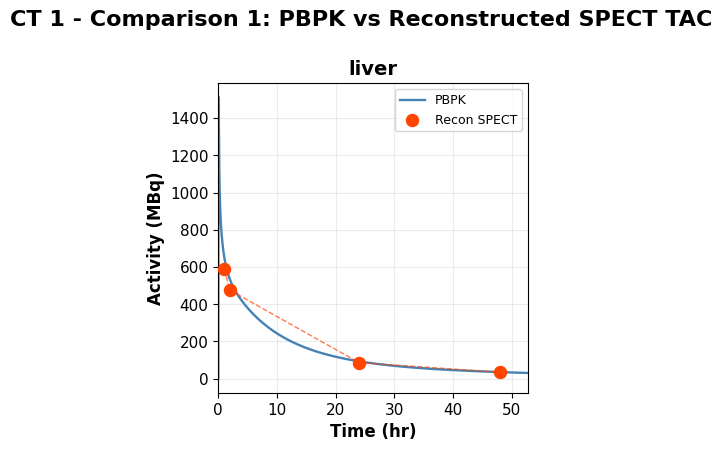

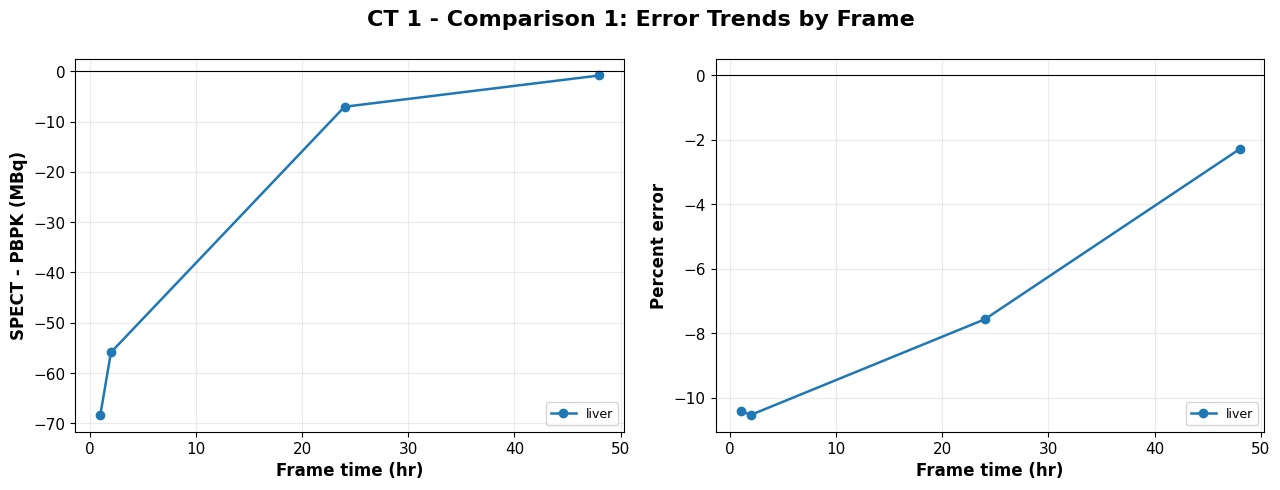


CT 1 - Comparison 1 table
  ROI                     frame         PBPK        SPECT        delta    pct_err
  liver                   1.00h      655.656      587.352      -68.304      -10.4%
  liver                   2.00h      530.974      475.091      -55.883      -10.5%
  liver                  24.00h       92.902       85.874       -7.028       -7.6%
  liver                  48.00h       35.180       34.376       -0.804       -2.3%


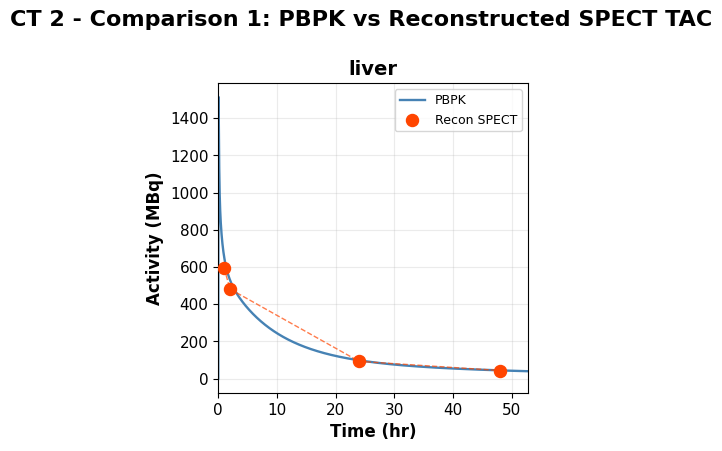

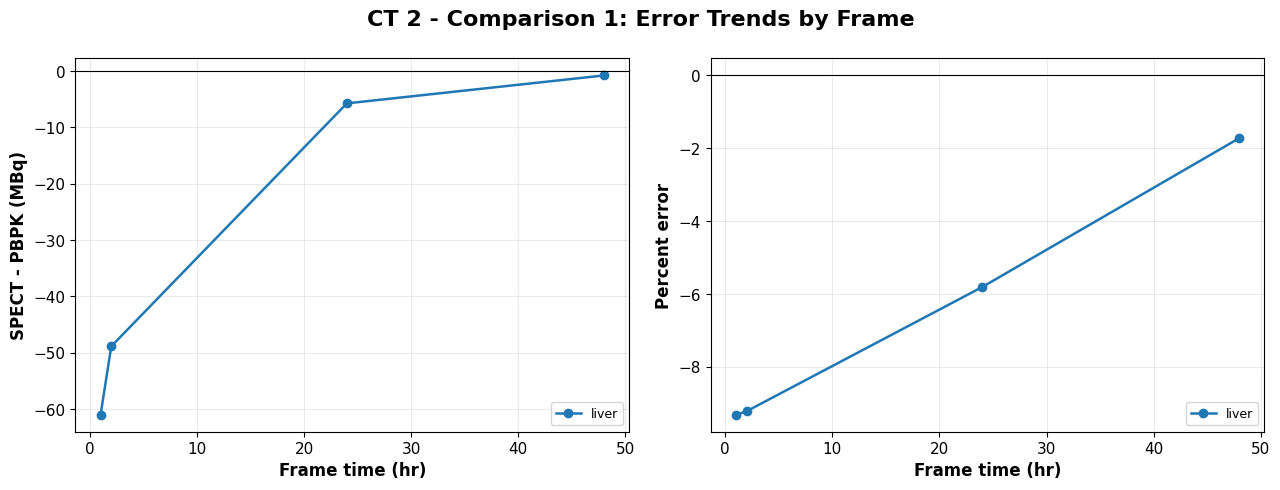


CT 2 - Comparison 1 table
  ROI                     frame         PBPK        SPECT        delta    pct_err
  liver                   1.00h      655.264      594.243      -61.021       -9.3%
  liver                   2.00h      530.334      481.468      -48.865       -9.2%
  liver                  24.00h       98.486       92.769       -5.718       -5.8%
  liver                  48.00h       44.365       43.602       -0.763       -1.7%


In [75]:
def simulated_rois_for_patient(i):
    rois = set()
    meta = simind_meta_store.get(i, {})
    rois.update(str(r).lower() for r in meta.get('roi_list', []) if r)
    if not rois:
        cfg_rois = configs.get(i, {}).get('phase_2', {}).get('simind_stage', {}).get('roi_subset', [])
        rois.update(str(r).lower() for r in cfg_rois if r)
    if not INCLUDE_REMAINING_BODY_IN_COMPARISON:
        rois.discard('remaining_body')
        rois.discard('body')
    return rois


def comparison_rois_for_patient(i, available_rois):
    candidates = []
    simulated = simulated_rois_for_patient(i) if COMPARE_ONLY_SIMULATED_ROIS else None
    for roi in available_rois:
        key = roi.lower()
        if key in SKIP_ROIS_COMPARISON:
            continue
        if not INCLUDE_REMAINING_BODY_IN_COMPARISON and key in {'remaining_body', 'body'}:
            continue
        if simulated is not None and simulated and key not in simulated:
            continue
        candidates.append(roi)
    return sorted(candidates)


def array_after_frame_filter(t, *ys):
    t = np.asarray(t, dtype=float)
    ys = [np.asarray(y, dtype=float) for y in ys]
    order = np.argsort(t)
    t = t[order]
    ys = [y[order] for y in ys]
    if SKIP_LAST_FRAME and len(t) > 1:
        t = t[:-1]
        ys = [y[:-1] for y in ys]
    return (t, *ys)


diff_store = {}

for i in spect_tacs:
    if i not in pbpk_store:
        print(f'CT {i+1}: no PBPK data for comparison')
        continue
    diff_store[i] = {}
    pbpk_t = pbpk_store[i]['time_hr']
    available = [r for r in spect_tacs[i] if spect_tacs[i][r]['sum_mbq']]
    plot_rois = comparison_rois_for_patient(i, available)

    skipped = sorted(set(available) - set(plot_rois))
    if skipped:
        print(f'CT {i+1}: comparison skipped ROIs={skipped}')
    if not plot_rois:
        print(f'CT {i+1}: no ROIs available after comparison filters')
        continue

    for roi in plot_rois:
        pbpk_key = roi.lower()
        if pbpk_key not in pbpk_store[i]:
            print(f'CT {i+1}: PBPK missing ROI {roi}')
            continue
        t_hr = np.array(spect_tacs[i][roi]['frame_hr'])
        y_s = np.array(spect_tacs[i][roi]['sum_mbq'])
        y_p = np.interp(t_hr, pbpk_t, pbpk_store[i][pbpk_key])
        t_hr, y_s, y_p = array_after_frame_filter(t_hr, y_s, y_p)
        diff_store[i][roi] = {
            'frame_hr': t_hr,
            'diff_mbq': y_s - y_p,
            'pct_err': pct(y_s, y_p),
            'y_spect': y_s,
            'y_pbpk': y_p,
        }

for i, diffs in diff_store.items():
    plot_rois = list(diffs)
    if not plot_rois:
        continue
    pbpk_t = pbpk_store[i]['time_hr']
    all_frames = np.concatenate([diffs[r]['frame_hr'] for r in plot_rois if len(diffs[r]['frame_hr'])])
    xlim = comparison_xlim(all_frames)

    fig, axes, nrows, ncols = make_grid(len(plot_rois), max_cols=4, panel_w=5.8, panel_h=4.6)
    fig.suptitle(f'CT {i+1} - Comparison 1: PBPK vs Reconstructed SPECT TAC')
    pbpk_color = plot_spec('comparison', 'pbpk_color', 'steelblue')
    spect_color = plot_spec('comparison', 'spect_color', 'orangered')

    for j, roi in enumerate(plot_rois):
        ax = axes[j // ncols][j % ncols]
        d = diffs[roi]
        ax.plot(pbpk_t, pbpk_store[i][roi.lower()], lw=1.7, color=pbpk_color, label='PBPK')
        ax.scatter(d['frame_hr'], d['y_spect'], s=75, color=spect_color, zorder=5, label='Recon SPECT')
        ax.plot(d['frame_hr'], d['y_spect'], '--', color=spect_color, lw=1, alpha=0.7)
        if xlim:
            ax.set_xlim(*xlim)
        ax.set_title(roi.replace('_', ' '))
        ax.set_xlabel('Time (hr)')
        ax.set_ylabel('Activity (MBq)')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.25)
        if FORCE_SQUARE_PANELS:
            ax.set_box_aspect(1)

    for j in range(len(plot_rois), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    finish_plot(fig, f'ct_{i+1}_comparison1_tac_overlay')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'CT {i+1} - Comparison 1: Error Trends by Frame')
    colors = plt.cm.tab10(np.linspace(0, 1, len(plot_rois)))
    for roi, col in zip(plot_rois, colors):
        d = diffs[roi]
        label = roi.replace('_', ' ')
        axes[0].plot(d['frame_hr'], d['diff_mbq'], marker='o', lw=1.8, color=col, label=label)
        axes[1].plot(d['frame_hr'], d['pct_err'], marker='o', lw=1.8, color=col, label=label)

    for ax, ylabel in zip(axes, ['SPECT - PBPK (MBq)', 'Percent error']):
        ax.axhline(0, color='k', lw=0.8)
        ax.set_xlabel('Frame time (hr)')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=9)
    finish_plot(fig, f'ct_{i+1}_comparison1_error_trends')

    print(f"\nCT {i+1} - Comparison 1 table")
    print(f"  {'ROI':20s} {'frame':>8s} {'PBPK':>12s} {'SPECT':>12s} {'delta':>12s} {'pct_err':>10s}")
    for roi in plot_rois:
        d = diffs[roi]
        for f_idx in range(len(d['frame_hr'])):
            print(f"  {roi:20s} {d['frame_hr'][f_idx]:7.2f}h "
                  f"{d['y_pbpk'][f_idx]:12.3f} {d['y_spect'][f_idx]:12.3f} "
                  f"{d['diff_mbq'][f_idx]:+12.3f} {d['pct_err'][f_idx]:+10.1f}%")

### 9b - Comparison 1 Average Across Patients

Expected output: average difference/error bars across all available patients. Missing ROIs are retained as NaN instead of silently removing all non-common ROIs.


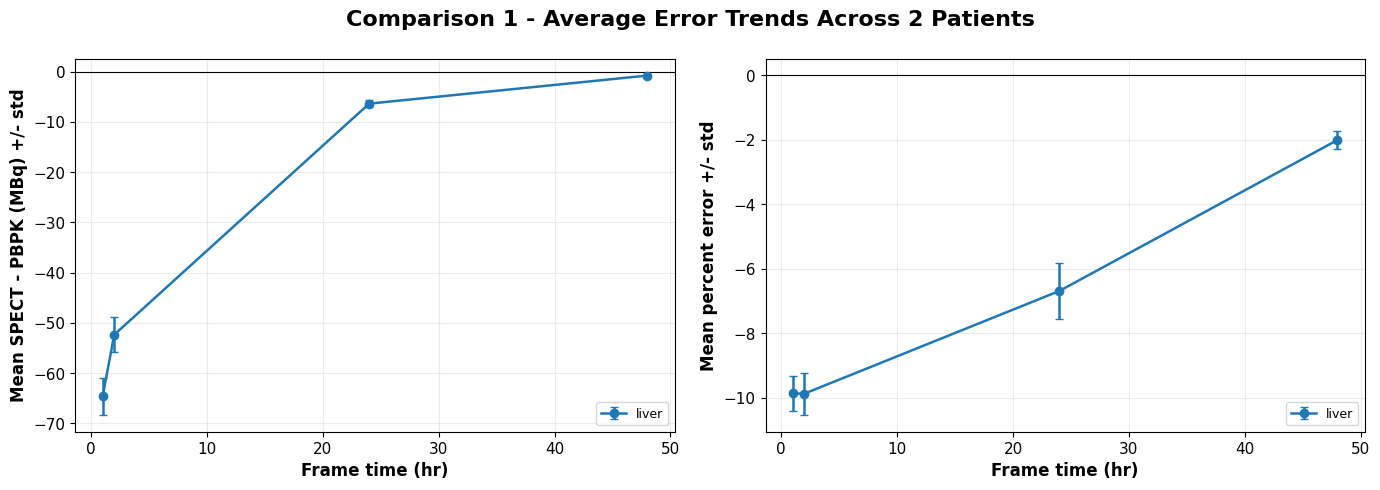

In [76]:
if len(diff_store) > 1:
    all_rois = sorted(set().union(*[set(d.keys()) for d in diff_store.values() if d]))
    all_frames = sorted(set(float(f) for d in diff_store.values() for r in d.values() for f in r['frame_hr']))

    if not all_rois or not all_frames:
        print('No comparable ROI/frame data available for cross-patient averaging')
    else:
        avg_diff = {roi: [] for roi in all_rois}
        avg_err = {roi: [] for roi in all_rois}
        std_diff = {roi: [] for roi in all_rois}
        std_err = {roi: [] for roi in all_rois}

        for roi in all_rois:
            for ft in all_frames:
                dvals, evals = [], []
                for i, patient_diffs in diff_store.items():
                    if roi not in patient_diffs:
                        dvals.append(np.nan); evals.append(np.nan); continue
                    frame_arr = np.asarray(patient_diffs[roi]['frame_hr'], dtype=float)
                    matches = np.where(np.isclose(frame_arr, ft, atol=1e-6))[0]
                    if matches.size:
                        idx = matches[0]
                        dvals.append(patient_diffs[roi]['diff_mbq'][idx])
                        evals.append(patient_diffs[roi]['pct_err'][idx])
                    else:
                        dvals.append(np.nan); evals.append(np.nan)
                avg_diff[roi].append(np.nanmean(dvals))
                avg_err[roi].append(np.nanmean(evals))
                std_diff[roi].append(np.nanstd(dvals))
                std_err[roi].append(np.nanstd(evals))

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Comparison 1 - Average Error Trends Across {len(diff_store)} Patients')
        colors = plt.cm.tab10(np.linspace(0, 1, len(all_rois)))
        for roi, col in zip(all_rois, colors):
            axes[0].errorbar(all_frames, avg_diff[roi], yerr=std_diff[roi], marker='o', lw=1.8, capsize=3, color=col, label=roi.replace('_', ' '))
            axes[1].errorbar(all_frames, avg_err[roi], yerr=std_err[roi], marker='o', lw=1.8, capsize=3, color=col, label=roi.replace('_', ' '))

        for ax, ylabel in zip(axes, ['Mean SPECT - PBPK (MBq) +/- std', 'Mean percent error +/- std']):
            ax.axhline(0, color='k', lw=0.8)
            ax.set_xlabel('Frame time (hr)')
            ax.set_ylabel(ylabel)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.25)
        finish_plot(fig, 'comparison1_average_error_trends')
else:
    print('Only 1 patient - cross-patient average skipped')

## 10 - Comparison 2: Bi-exponential Kinetics

Expected output: PBPK and SPECT bi-exponential fits for comparable ROIs. Treat these fits as exploratory when there are only a few SPECT frames.


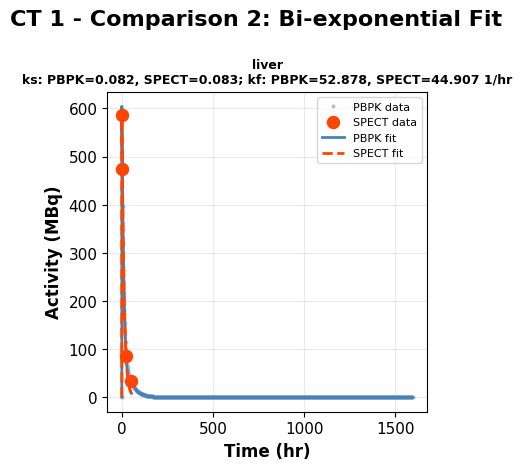


CT 1 - Kinetic Parameter Comparison
  ROI                   k_slow_PBPK  k_slow_SPECT       pct  k_fast_PBPK  k_fast_SPECT       pct
  liver                      0.0821        0.0828      +0.8%      52.8784       44.9068     -15.1%


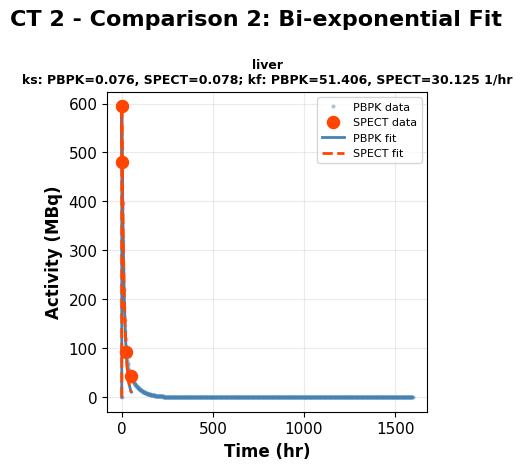


CT 2 - Kinetic Parameter Comparison
  ROI                   k_slow_PBPK  k_slow_SPECT       pct  k_fast_PBPK  k_fast_SPECT       pct
  liver                      0.0762        0.0781      +2.5%      51.4063       30.1254     -41.4%


In [77]:
def biexp(t, A, k_slow, delta):
    return A * (np.exp(-k_slow * t) - np.exp(-(k_slow + delta) * t))


def downsample_xy(t, y, max_points):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if t.size <= max_points:
        return t, y
    idx = np.unique(np.linspace(0, t.size - 1, max_points).astype(int))
    return t[idx], y[idx]


def fit_biexp(t, y):
    t, y = np.asarray(t, float), np.asarray(y, float)
    mask = np.isfinite(t) & np.isfinite(y) & (y >= 0)
    t, y = t[mask], y[mask]
    if t.size < 3:
        raise ValueError(f'Need at least 3 points, got {t.size}')
    p0 = [max(float(np.max(y)) * 2.0, 1e-6), 0.05, 1.0]
    bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', OptimizeWarning)
        popt, _ = curve_fit(biexp, t, y, p0=p0, bounds=bounds, maxfev=50000)
    return popt


fit_store = {}

for i in spect_tacs:
    if i not in pbpk_store:
        continue
    fit_store[i] = {}
    pbpk_t = pbpk_store[i]['time_hr']
    available = [r for r in spect_tacs[i] if r.lower() in pbpk_store[i] and len(spect_tacs[i][r]['sum_mbq']) >= 3]
    plot_rois = comparison_rois_for_patient(i, available)

    if not plot_rois:
        print(f'CT {i+1}: insufficient comparable frames/ROIs for bi-exp fit')
        continue

    fig, axes, nrows, ncols = make_grid(len(plot_rois), max_cols=4, panel_w=5.8, panel_h=4.8)
    fig.suptitle(f'CT {i+1} - Comparison 2: Bi-exponential Fit')
    pbpk_color = plot_spec('comparison', 'pbpk_color', 'steelblue')
    spect_color = plot_spec('comparison', 'spect_color', 'orangered')

    for j, roi in enumerate(plot_rois):
        ax = axes[j // ncols][j % ncols]
        y_pbpk = pbpk_store[i][roi.lower()]
        t_fit_p, y_fit_p = downsample_xy(pbpk_t, y_pbpk, FIT_MAX_PBPK_POINTS)

        popt_p = popt_s = None
        try:
            popt_p = fit_biexp(t_fit_p, y_fit_p)
            t_plot_p, y_plot_p = downsample_xy(pbpk_t, y_pbpk, 700)
            ax.plot(t_plot_p, y_plot_p, 'o', ms=2, color=pbpk_color, alpha=0.35, label='PBPK data')
        except Exception as e:
            print(f'  CT {i+1} {roi} PBPK fit failed: {e}')

        t_s = np.array(spect_tacs[i][roi]['frame_hr'])
        y_s = np.array(spect_tacs[i][roi]['sum_mbq'])
        t_s, y_s = array_after_frame_filter(t_s, y_s)
        try:
            popt_s = fit_biexp(t_s, y_s)
            ax.scatter(t_s, y_s, s=75, color=spect_color, zorder=5, label='SPECT data')
        except Exception as e:
            print(f'  CT {i+1} {roi} SPECT fit failed: {e}')

        plot_end = max(float(np.max(t_s)) * 1.10 if len(t_s) else 1.0, 1.0)
        t_grid = np.linspace(0, plot_end, 400)
        if popt_p is not None:
            ax.plot(t_grid, biexp(t_grid, *popt_p), lw=2, color=pbpk_color, label='PBPK fit')
        if popt_s is not None:
            ax.plot(t_grid, biexp(t_grid, *popt_s), '--', lw=2, color=spect_color, label='SPECT fit')
        if popt_p is not None and popt_s is not None:
            fit_store[i][roi] = {'pbpk': popt_p, 'spect': popt_s}
            kf_p = popt_p[1] + popt_p[2]
            kf_s = popt_s[1] + popt_s[2]
            ax.set_title(f"{roi.replace('_', ' ')}\nks: PBPK={popt_p[1]:.3f}, SPECT={popt_s[1]:.3f}; "
                         f"kf: PBPK={kf_p:.3f}, SPECT={kf_s:.3f} 1/hr", fontsize=9)
        else:
            ax.set_title(roi.replace('_', ' '))
        ax.set_xlabel('Time (hr)')
        ax.set_ylabel('Activity (MBq)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)
        if FORCE_SQUARE_PANELS:
            ax.set_box_aspect(1)

    for j in range(len(plot_rois), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    finish_plot(fig, f'ct_{i+1}_comparison2_biexp_fit')

    print(f"\nCT {i+1} - Kinetic Parameter Comparison")
    print(f"  {'ROI':20s} {'k_slow_PBPK':>12s} {'k_slow_SPECT':>13s} {'pct':>9s} "
          f"{'k_fast_PBPK':>12s} {'k_fast_SPECT':>13s} {'pct':>9s}")
    for roi, fits in fit_store.get(i, {}).items():
        pp, ps = fits['pbpk'], fits['spect']
        ks_p, ks_s = pp[1], ps[1]
        kf_p, kf_s = pp[1] + pp[2], ps[1] + ps[2]
        print(f"  {roi:20s} {ks_p:12.4f} {ks_s:13.4f} {pct(ks_s, ks_p):+9.1f}% "
              f"{kf_p:12.4f} {kf_s:13.4f} {pct(kf_s, kf_p):+9.1f}%")


### 10b - Average Kinetic Parameters Across Patients

Expected output: cross-patient kinetic summary. Missing ROIs are handled as NaN instead of forcing an intersection-only view.


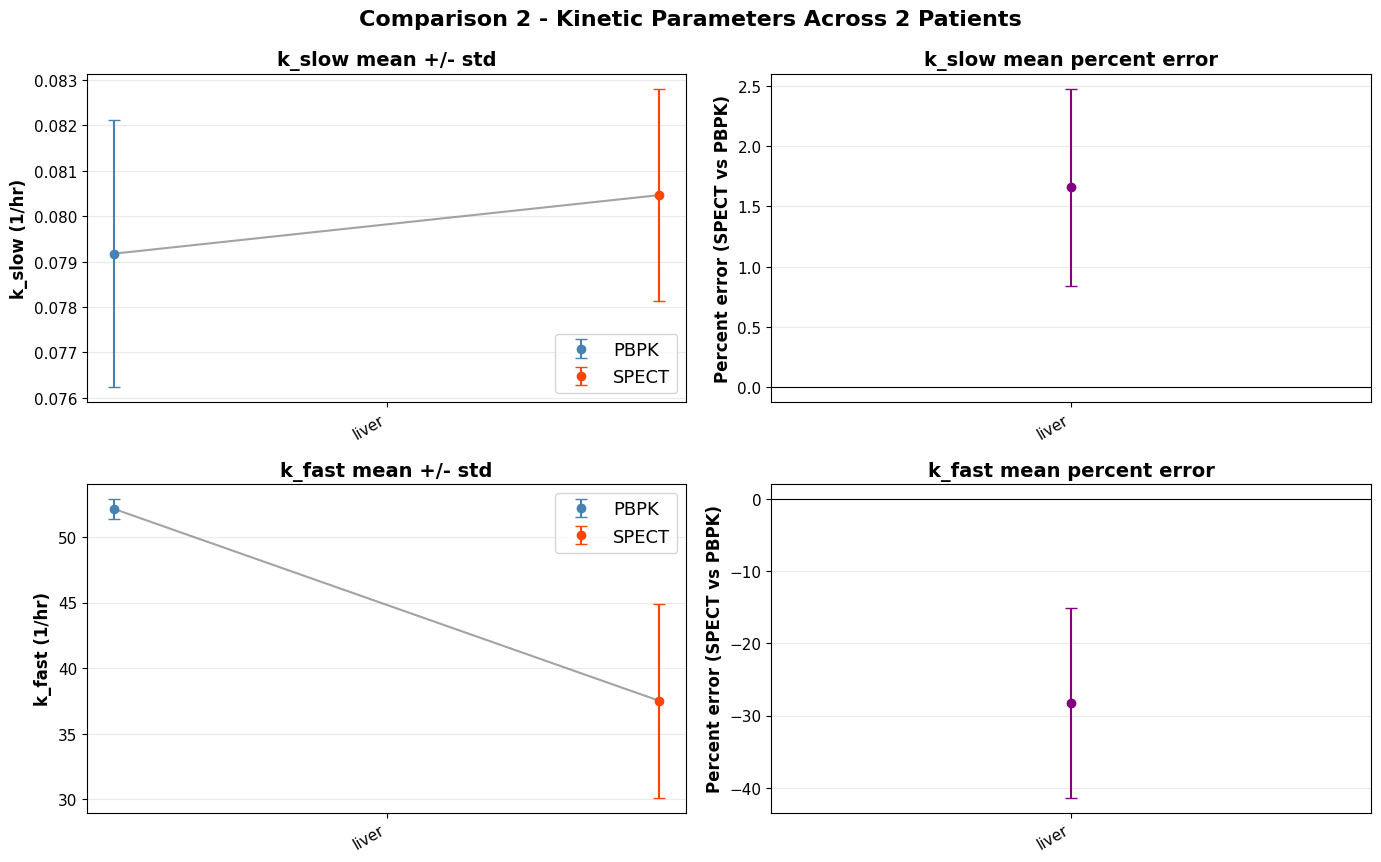

In [78]:
if len(fit_store) > 1:
    all_rois = sorted(set().union(*[set(v.keys()) for v in fit_store.values() if v]))
    if not all_rois:
        print('No fitted ROIs available for cross-patient kinetic summary')
    else:
        param_defs = [('k_slow', lambda p: p[1]), ('k_fast', lambda p: p[1] + p[2])]
        fig, axes = plt.subplots(len(param_defs), 2, figsize=(14, 4.4 * len(param_defs)), squeeze=False)
        fig.suptitle(f'Comparison 2 - Kinetic Parameters Across {len(fit_store)} Patients')
        x = np.arange(len(all_rois))

        for row, (pname, getter) in enumerate(param_defs):
            means_p, means_s, stds_p, stds_s, pcts, pct_sd = [], [], [], [], [], []
            for roi in all_rois:
                vals_p, vals_s, vals_pct = [], [], []
                for i, fits in fit_store.items():
                    if roi not in fits:
                        vals_p.append(np.nan); vals_s.append(np.nan); vals_pct.append(np.nan); continue
                    vp = getter(fits[roi]['pbpk'])
                    vs = getter(fits[roi]['spect'])
                    vals_p.append(vp); vals_s.append(vs); vals_pct.append(pct(vs, vp))
                means_p.append(np.nanmean(vals_p)); means_s.append(np.nanmean(vals_s))
                stds_p.append(np.nanstd(vals_p)); stds_s.append(np.nanstd(vals_s))
                pcts.append(np.nanmean(vals_pct)); pct_sd.append(np.nanstd(vals_pct))

            ax = axes[row][0]
            for xi, vp, vs in zip(x, means_p, means_s):
                ax.plot([xi - 0.12, xi + 0.12], [vp, vs], color='0.55', lw=1.5, alpha=0.8)
            ax.errorbar(x - 0.12, means_p, yerr=stds_p, fmt='o', color='steelblue', capsize=4, label='PBPK')
            ax.errorbar(x + 0.12, means_s, yerr=stds_s, fmt='o', color='orangered', capsize=4, label='SPECT')
            ax.set_xticks(x); ax.set_xticklabels([r.replace('_',' ') for r in all_rois], rotation=30, ha='right')
            ax.set_ylabel(f'{pname} (1/hr)'); ax.set_title(f'{pname} mean +/- std'); ax.legend(); ax.grid(True, axis='y', alpha=0.25)

            ax2 = axes[row][1]
            ax2.errorbar(x, pcts, yerr=pct_sd, fmt='o', color='purple', capsize=4)
            ax2.axhline(0, color='k', lw=0.8)
            ax2.set_xticks(x); ax2.set_xticklabels([r.replace('_',' ') for r in all_rois], rotation=30, ha='right')
            ax2.set_ylabel('Percent error (SPECT vs PBPK)'); ax2.set_title(f'{pname} mean percent error'); ax2.grid(True, axis='y', alpha=0.25)
        finish_plot(fig, 'comparison2_average_kinetics')
else:
    print('Only 1 patient - cross-patient kinetic comparison skipped')

## 11 - Comparison 3: AUC

Expected output: PBPK AUC compared with SPECT fit AUC and direct trapezoid SPECT AUC. The default integration end is the final included SPECT frame.


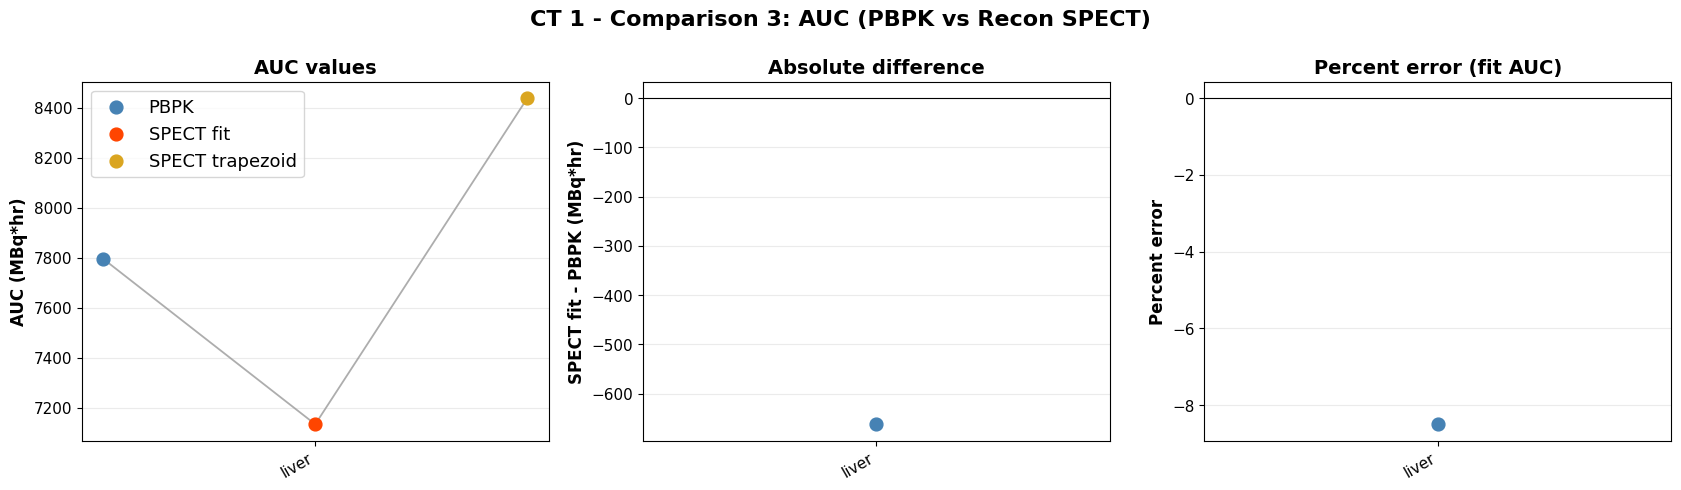


CT 1 - AUC table
  ROI                     t_end         PBPK    SPECT_fit   SPECT_trap    fit_pct
  liver                  48.00h     7795.551     7133.051     8438.510       -8.5%


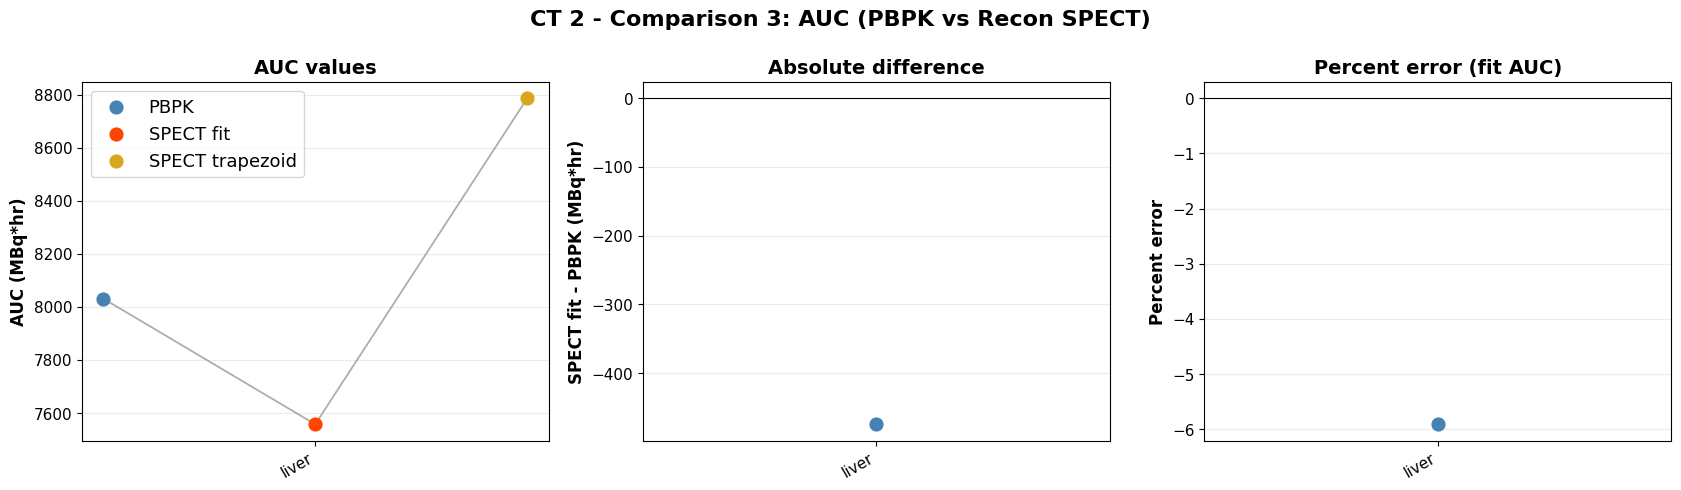


CT 2 - AUC table
  ROI                     t_end         PBPK    SPECT_fit   SPECT_trap    fit_pct
  liver                  48.00h     8031.973     7557.416     8788.030       -5.9%


In [79]:
def pbpk_auc(t_hr, y_mbq, t_end_hr):
    t, y = np.asarray(t_hr, float), np.asarray(y_mbq, float)
    mask = np.isfinite(t) & np.isfinite(y)
    t, y = t[mask], y[mask]
    order = np.argsort(t); t, y = t[order], y[order]
    if t.size == 0:
        return np.nan
    t_end_use = min(float(t_end_hr), float(t[-1]))
    keep = t <= t_end_use
    tu, yu = t[keep], y[keep]
    if tu.size == 0:
        return np.nan
    if tu[-1] < t_end_use:
        tu = np.append(tu, t_end_use)
        yu = np.append(yu, float(np.interp(t_end_use, t, y)))
    return float(np.trapezoid(yu, tu))


def spect_auc_analytic(popt, t_end_hr):
    A, ks, delta = [float(v) for v in popt]
    kf = ks + delta
    if not all(np.isfinite([A, ks, kf])) or ks <= 0 or kf <= 0:
        return np.nan
    T = float(t_end_hr)
    return A * ((1 - np.exp(-ks * T)) / ks - (1 - np.exp(-kf * T)) / kf)


def spect_auc_trapezoid(t_hr, y_mbq, t_end_hr):
    t, y = np.asarray(t_hr, float), np.asarray(y_mbq, float)
    t, y = array_after_frame_filter(t, y)
    order = np.argsort(t); t, y = t[order], y[order]
    if t.size == 0:
        return np.nan
    T = float(t_end_hr)
    keep = t <= T
    t, y = t[keep], y[keep]
    if t.size == 0 or t[0] > 0:
        t = np.insert(t, 0, 0.0)
        y = np.insert(y, 0, 0.0)
    if t[-1] < T:
        t = np.append(t, T)
        y = np.append(y, float(np.interp(T, t[:-1], y[:-1])))
    return float(np.trapezoid(y, t))


auc_store = {}

for i in fit_store:
    if i not in pbpk_store:
        continue
    auc_store[i] = {}
    pbpk_t = pbpk_store[i]['time_hr']

    for roi, fits in fit_store[i].items():
        t_s = np.array(spect_tacs[i][roi]['frame_hr'])
        y_s = np.array(spect_tacs[i][roi]['sum_mbq'])
        t_use, y_use = array_after_frame_filter(t_s, y_s)
        t_end = float(t_use[-1]) if len(t_use) > 0 else float(pbpk_t[-1])

        auc_p = pbpk_auc(pbpk_t, pbpk_store[i][roi.lower()], t_end)
        auc_s_fit = spect_auc_analytic(fits['spect'], t_end)
        auc_s_trap = spect_auc_trapezoid(t_s, y_s, t_end)

        auc_store[i][roi] = {
            'pbpk_auc': auc_p,
            'spect_auc_fit': auc_s_fit,
            'spect_auc_trap': auc_s_trap,
            't_end_hr': t_end,
        }

for i, aucs in auc_store.items():
    if not aucs:
        continue
    rois = list(aucs.keys())
    x = np.arange(len(rois))
    pbpk_vals = [aucs[r]['pbpk_auc'] for r in rois]
    fit_vals = [aucs[r]['spect_auc_fit'] for r in rois]
    trap_vals = [aucs[r]['spect_auc_trap'] for r in rois]
    pct_vals = [pct(aucs[r]['spect_auc_fit'], aucs[r]['pbpk_auc']) for r in rois]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(f'CT {i+1} - Comparison 3: AUC (PBPK vs Recon SPECT)')
    for xi, vp, vf, vt in zip(x, pbpk_vals, fit_vals, trap_vals):
        axes[0].plot([xi - 0.18, xi, xi + 0.18], [vp, vf, vt], color='0.6', lw=1.3, alpha=0.8)
    axes[0].scatter(x - 0.18, pbpk_vals, s=85, color='steelblue', label='PBPK', zorder=4)
    axes[0].scatter(x, fit_vals, s=85, color='orangered', label='SPECT fit', zorder=4)
    axes[0].scatter(x + 0.18, trap_vals, s=85, color='goldenrod', label='SPECT trapezoid', zorder=4)
    axes[0].set_ylabel('AUC (MBq*hr)'); axes[0].set_title('AUC values'); axes[0].legend(); axes[0].grid(True, axis='y', alpha=0.25)

    diff_vals = [fit_vals[k] - pbpk_vals[k] for k in range(len(rois))]
    axes[1].scatter(x, diff_vals, s=85, color=['tomato' if v > 0 else 'steelblue' for v in diff_vals], zorder=4)
    axes[1].axhline(0, color='k', lw=0.8)
    axes[1].set_ylabel('SPECT fit - PBPK (MBq*hr)'); axes[1].set_title('Absolute difference'); axes[1].grid(True, axis='y', alpha=0.25)

    axes[2].scatter(x, pct_vals, s=85, color=['tomato' if v > 0 else 'steelblue' for v in pct_vals], zorder=4)
    axes[2].axhline(0, color='k', lw=0.8)
    axes[2].set_ylabel('Percent error'); axes[2].set_title('Percent error (fit AUC)'); axes[2].grid(True, axis='y', alpha=0.25)

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels([r.replace('_', ' ') for r in rois], rotation=30, ha='right')
    finish_plot(fig, f'ct_{i+1}_comparison3_auc')

    print(f"\nCT {i+1} - AUC table")
    print(f"  {'ROI':20s} {'t_end':>8s} {'PBPK':>12s} {'SPECT_fit':>12s} {'SPECT_trap':>12s} {'fit_pct':>10s}")
    for roi in rois:
        a = aucs[roi]
        print(f"  {roi:20s} {a['t_end_hr']:7.2f}h {a['pbpk_auc']:12.3f} "
              f"{a['spect_auc_fit']:12.3f} {a['spect_auc_trap']:12.3f} "
              f"{pct(a['spect_auc_fit'], a['pbpk_auc']):+10.1f}%")

### 11b - Average AUC Across Patients

Expected output: average AUC summary across all available patients/ROIs, retaining missing entries as NaN.


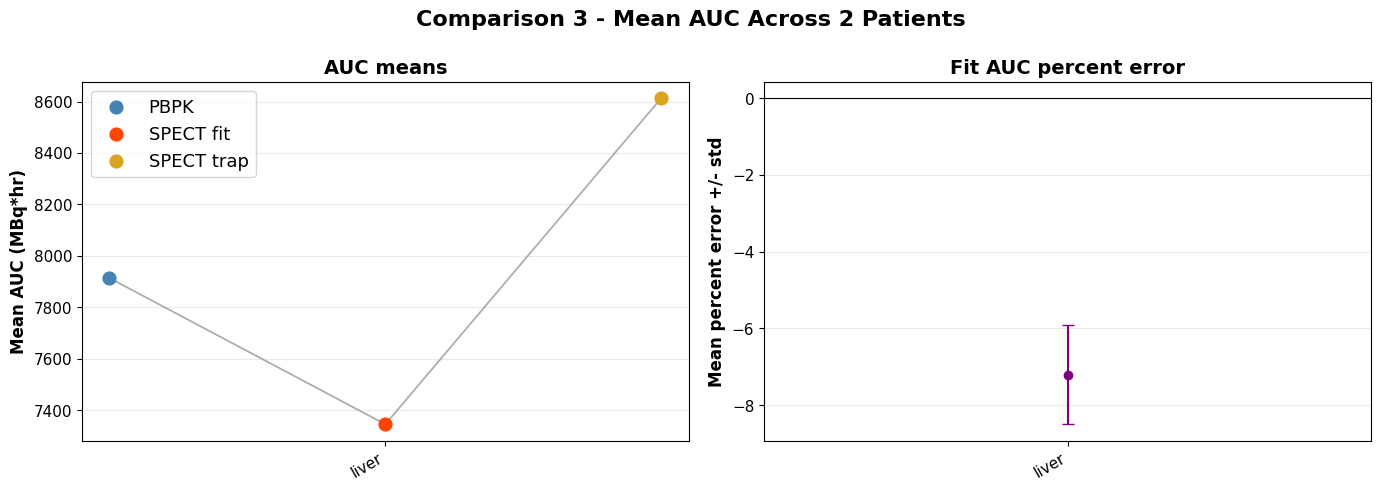

In [80]:
if len(auc_store) > 1:
    all_rois = sorted(set().union(*[set(v.keys()) for v in auc_store.values() if v]))
    if not all_rois:
        print('No AUC data available for cross-patient summary')
    else:
        roi_acc = {r: {'pbpk': [], 'fit': [], 'trap': [], 'pct_fit': []} for r in all_rois}
        for i, patient_aucs in auc_store.items():
            for roi in all_rois:
                if roi not in patient_aucs:
                    for key in roi_acc[roi]:
                        roi_acc[roi][key].append(np.nan)
                    continue
                a = patient_aucs[roi]
                roi_acc[roi]['pbpk'].append(a['pbpk_auc'])
                roi_acc[roi]['fit'].append(a['spect_auc_fit'])
                roi_acc[roi]['trap'].append(a['spect_auc_trap'])
                roi_acc[roi]['pct_fit'].append(pct(a['spect_auc_fit'], a['pbpk_auc']))

        x = np.arange(len(all_rois))
        mp = [np.nanmean(roi_acc[r]['pbpk']) for r in all_rois]
        mf = [np.nanmean(roi_acc[r]['fit']) for r in all_rois]
        mt = [np.nanmean(roi_acc[r]['trap']) for r in all_rois]
        me = [np.nanmean(roi_acc[r]['pct_fit']) for r in all_rois]
        se = [np.nanstd(roi_acc[r]['pct_fit']) for r in all_rois]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Comparison 3 - Mean AUC Across {len(auc_store)} Patients')
        for xi, vp, vf, vt in zip(x, mp, mf, mt):
            axes[0].plot([xi - 0.18, xi, xi + 0.18], [vp, vf, vt], color='0.6', lw=1.3, alpha=0.8)
        axes[0].scatter(x - 0.18, mp, s=85, color='steelblue', label='PBPK', zorder=4)
        axes[0].scatter(x, mf, s=85, color='orangered', label='SPECT fit', zorder=4)
        axes[0].scatter(x + 0.18, mt, s=85, color='goldenrod', label='SPECT trap', zorder=4)
        axes[0].set_ylabel('Mean AUC (MBq*hr)'); axes[0].set_title('AUC means'); axes[0].legend(); axes[0].grid(True, axis='y', alpha=0.25)

        axes[1].errorbar(x, me, yerr=se, fmt='o', color='purple', capsize=4)
        axes[1].axhline(0, color='k', lw=0.8)
        axes[1].set_ylabel('Mean percent error +/- std'); axes[1].set_title('Fit AUC percent error'); axes[1].grid(True, axis='y', alpha=0.25)

        for ax in axes:
            ax.set_xticks(x)
            ax.set_xticklabels([r.replace('_', ' ') for r in all_rois], rotation=30, ha='right')
        finish_plot(fig, 'comparison3_average_auc')
else:
    print('Only 1 patient - cross-patient AUC comparison skipped')

## 12 - CPU and RAM Profiling

Expected output: profiling summaries and plots if the pipeline was run with `--profile`. CPU is reported as percent of total machine capacity, so 100 means all logical cores are fully used.


In [81]:
profiles = {}
profile_summary_store = {}


def summarize_profile(prof):
    rows = []
    cpu_count = prof.get('logical_cpu_count', 1)
    for s in prof.get('stages', []):
        cpu = np.asarray(s.get('cpu_pct_samples', []), dtype=float)
        ram = np.asarray(s.get('ram_mb_samples', []), dtype=float)
        rows.append({
            'name': s.get('name', 'unknown'),
            'elapsed_s': float(s.get('elapsed_s', 0.0)),
            'samples': int(cpu.size),
            'mean_cpu_capacity_pct': float(np.nanmean(cpu / cpu_count)) if cpu.size else np.nan,
            'max_cpu_capacity_pct': float(np.nanmax(cpu / cpu_count)) if cpu.size else np.nan,
            'mean_cpu_cores': float(np.nanmean(cpu / 100.0)) if cpu.size else np.nan,
            'max_cpu_cores': float(np.nanmax(cpu / 100.0)) if cpu.size else np.nan,
            'peak_ram_gb': float(np.nanmax(ram) / 1024.0) if ram.size else np.nan,
            'mean_ram_gb': float(np.nanmean(ram) / 1024.0) if ram.size else np.nan,
        })
    return rows


for i, folder in enumerate(OUT_FOLDERS):
    hits = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                   if f.startswith('profiling_CT_') and f.endswith('.json')]) if os.path.isdir(folder) else []
    if not hits:
        print(f'CT {i+1}: no profiling file (run with --profile)')
        continue
    with open(hits[0], encoding='utf-8') as f:
        profiles[i] = json.load(f)
    profile_summary_store[i] = summarize_profile(profiles[i])
    stages = [s['name'] for s in profiles[i].get('stages', [])]
    print(f"\nCT {i+1}: {len(stages)} stages, total={profiles[i].get('pipeline_total_elapsed_s', 0):.1f}s, logical CPUs={profiles[i].get('logical_cpu_count', '-')}")
    print(f'  stages: {stages}')
    print(f"  {'stage':22s} {'elapsed_s':>10s} {'mean_CPU%':>10s} {'max_CPU%':>9s} {'peak_RAM_GB':>12s}")
    for row in profile_summary_store[i]:
        print(f"  {row['name']:22s} {row['elapsed_s']:10.1f} {row['mean_cpu_capacity_pct']:10.1f} "
              f"{row['max_cpu_capacity_pct']:9.1f} {row['peak_ram_gb']:12.2f}")

if not profiles:
    print('\nNo profiling data available - re-run with --profile to enable profiling plots.')



CT 1: 7 stages, total=17018.9s, logical CPUs=112
  stages: ['segmentation', 'synthetic_lesions', 'pbpk_tac', 'simind', 'opengate', 'spect_postprocess', 'dosemap_postprocess']
  stage                   elapsed_s  mean_CPU%  max_CPU%  peak_RAM_GB
  segmentation                830.6        7.4     102.9        14.43
  synthetic_lesions            31.0        0.9       1.0         5.19
  pbpk_tac                      2.0        0.9       0.9         2.08
  simind                    12386.0       97.2     100.3        22.24
  opengate                   3548.3       36.9      97.9       175.31
  spect_postprocess           215.3       34.2      39.2        11.68
  dosemap_postprocess           5.2        0.9       0.9         9.57

CT 2: 6 stages, total=2636.1s, logical CPUs=112
  stages: ['segmentation', 'pbpk_tac', 'simind', 'opengate', 'spect_postprocess', 'dosemap_postprocess']
  stage                   elapsed_s  mean_CPU%  max_CPU%  peak_RAM_GB
  segmentation                590.8     

### 12a - Full Pipeline CPU/RAM Timeline

Expected output: one timeline per patient with stage boundaries preserved. This is better for spotting long-running or memory-heavy stages than per-stage plots alone.


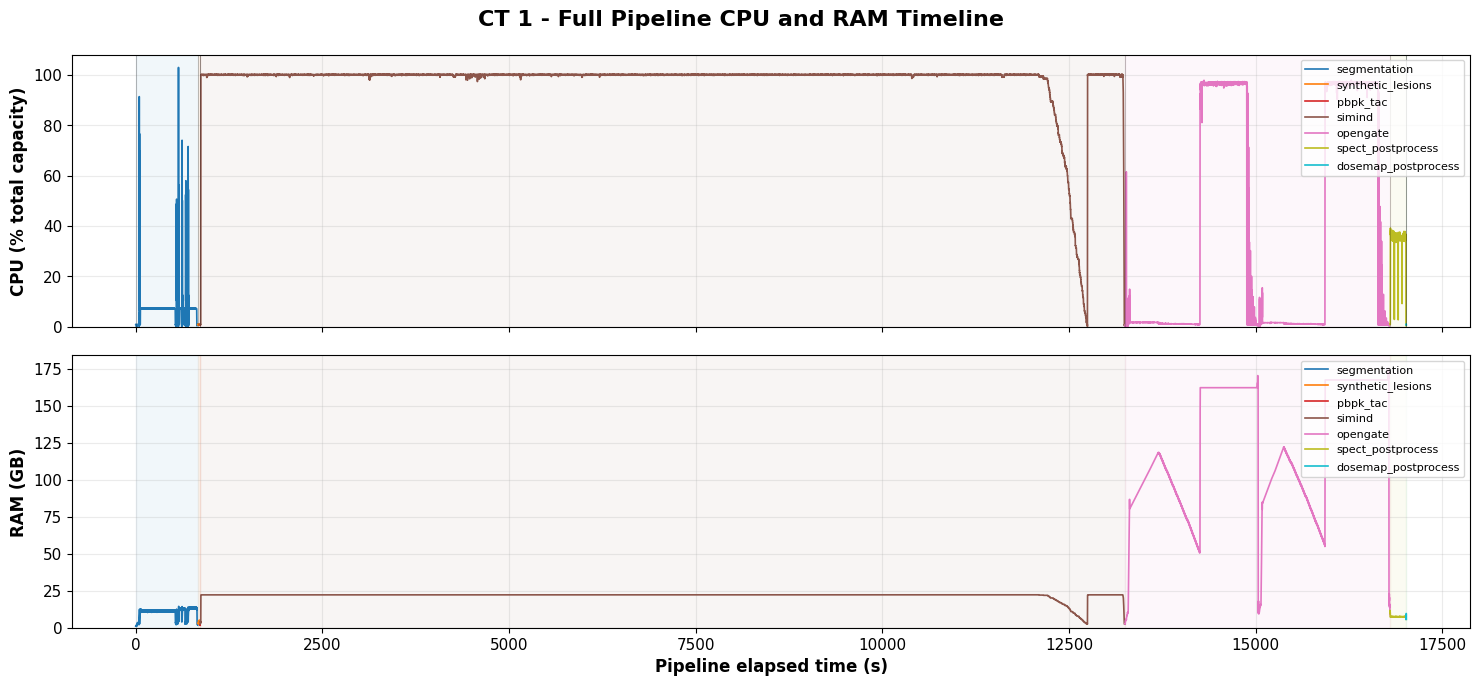

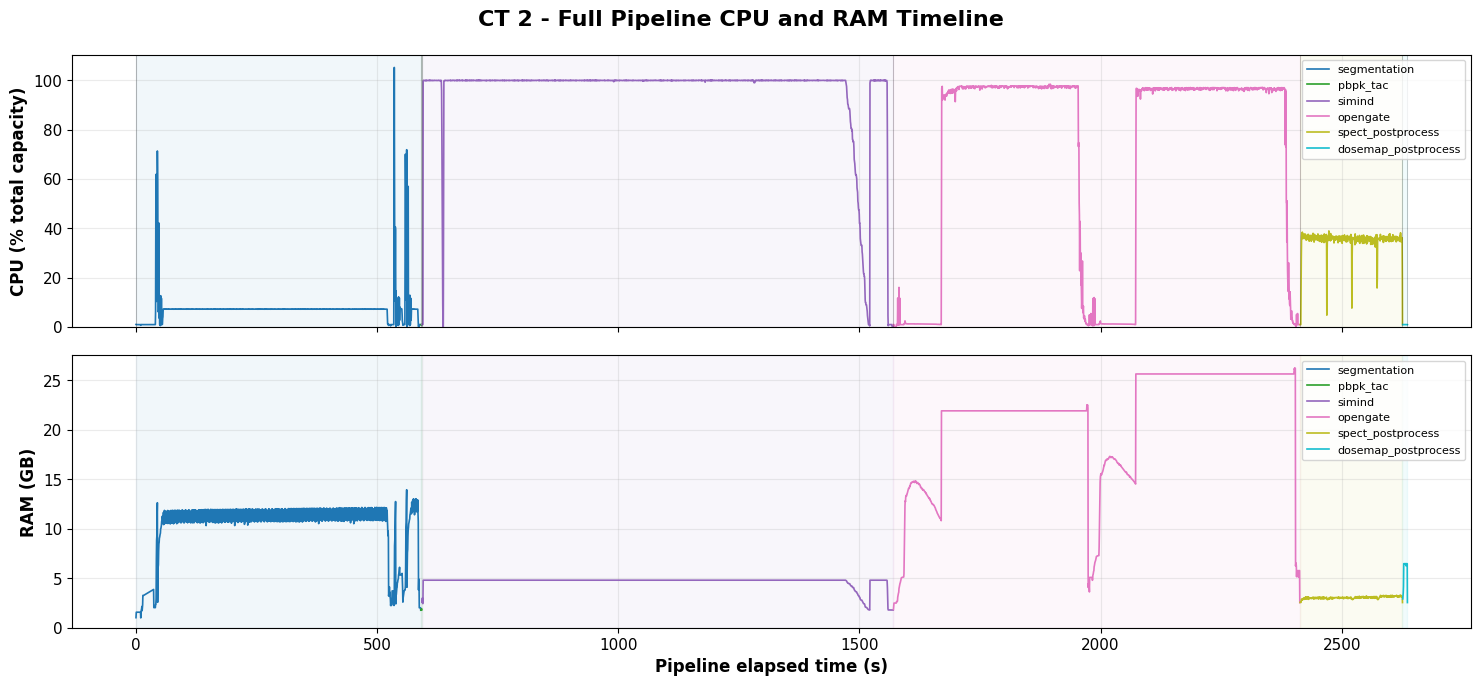

In [82]:
for i, prof in profiles.items():
    stages = prof.get('stages', [])
    cpu_count = prof.get('logical_cpu_count', 1)
    if not stages:
        continue

    colors = plt.get_cmap(plot_spec('profile', 'cmap', 'tab10'))(np.linspace(0, 1, len(stages)))
    fig, (ax_cpu, ax_ram) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
    fig.suptitle(f'CT {i+1} - Full Pipeline CPU and RAM Timeline')

    offset = 0.0
    for s, col in zip(stages, colors):
        elapsed = float(s.get('elapsed_s', 0.0))
        t = np.asarray(s.get('sample_times_s', []), dtype=float) + offset
        cpu = np.asarray(s.get('cpu_pct_samples', []), dtype=float) / cpu_count
        ram = np.asarray(s.get('ram_mb_samples', []), dtype=float) / 1024.0
        name = s.get('name', 'unknown')
        if t.size:
            ax_cpu.plot(t, cpu, lw=1.2, color=col, label=name)
            ax_ram.plot(t, ram, lw=1.2, color=col, label=name)
        ax_cpu.axvspan(offset, offset + elapsed, color=col, alpha=0.06)
        ax_ram.axvspan(offset, offset + elapsed, color=col, alpha=0.06)
        ax_cpu.axvline(offset, color='k', lw=0.5, alpha=0.3)
        offset += elapsed
    ax_cpu.axvline(offset, color='k', lw=0.5, alpha=0.3)

    ax_cpu.set_ylabel('CPU (% total capacity)')
    ax_ram.set_ylabel('RAM (GB)')
    ax_ram.set_xlabel('Pipeline elapsed time (s)')
    for ax in (ax_cpu, ax_ram):
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc='upper right')
        ax.set_ylim(bottom=0)
    finish_plot(fig, f'ct_{i+1}_profile_full_timeline')


### 12b - Cross-Patient Stage CPU/RAM Comparison

Expected output: one comparison plot per stage, filtered by `PROFILE_PHASE` if set.


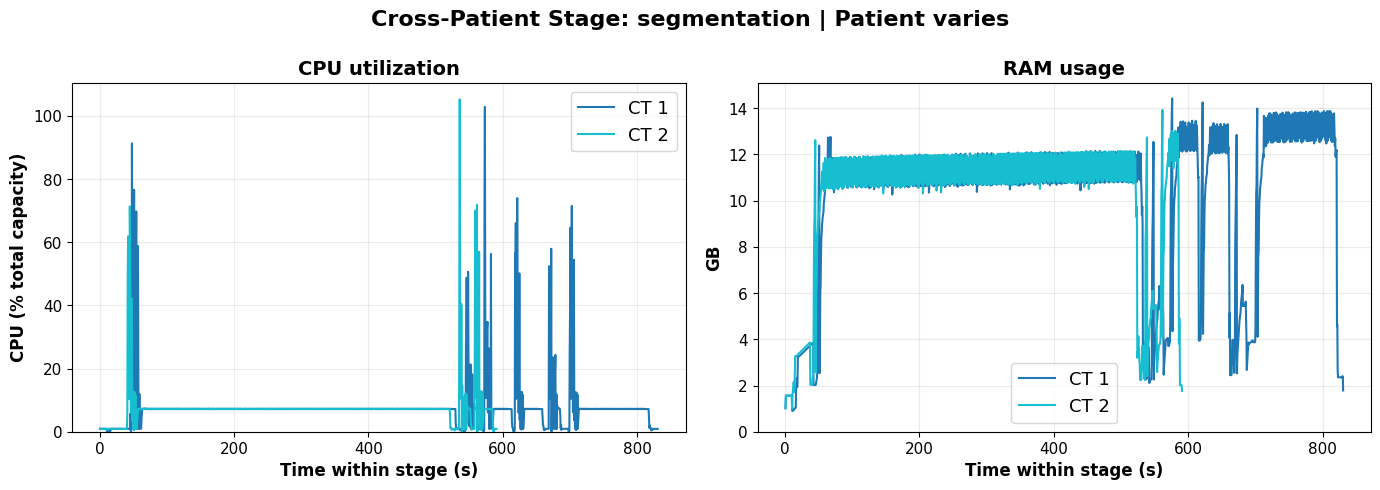

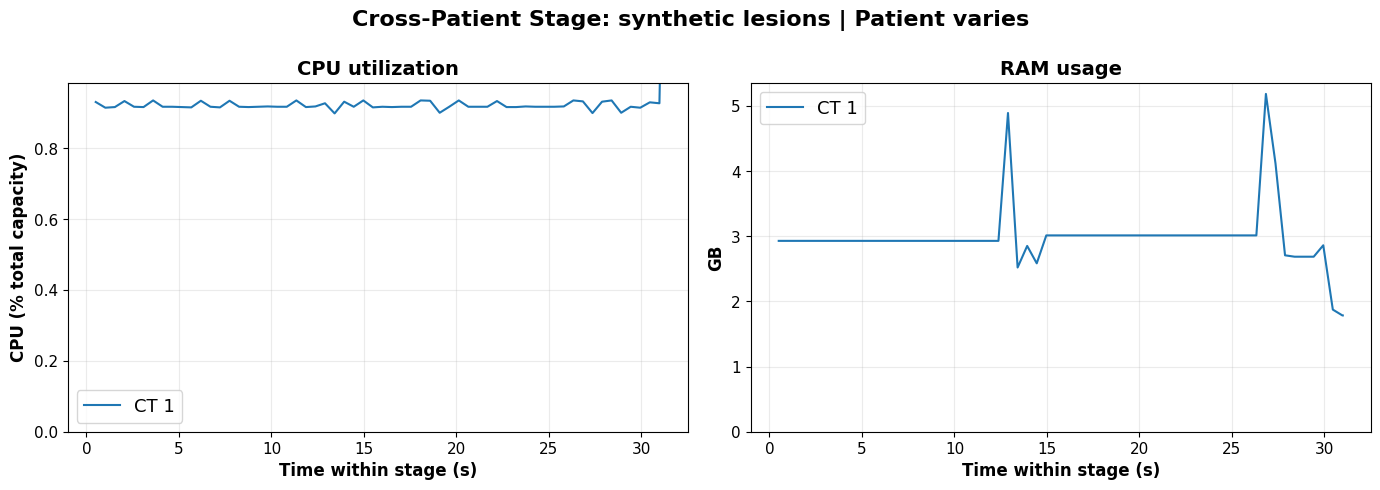

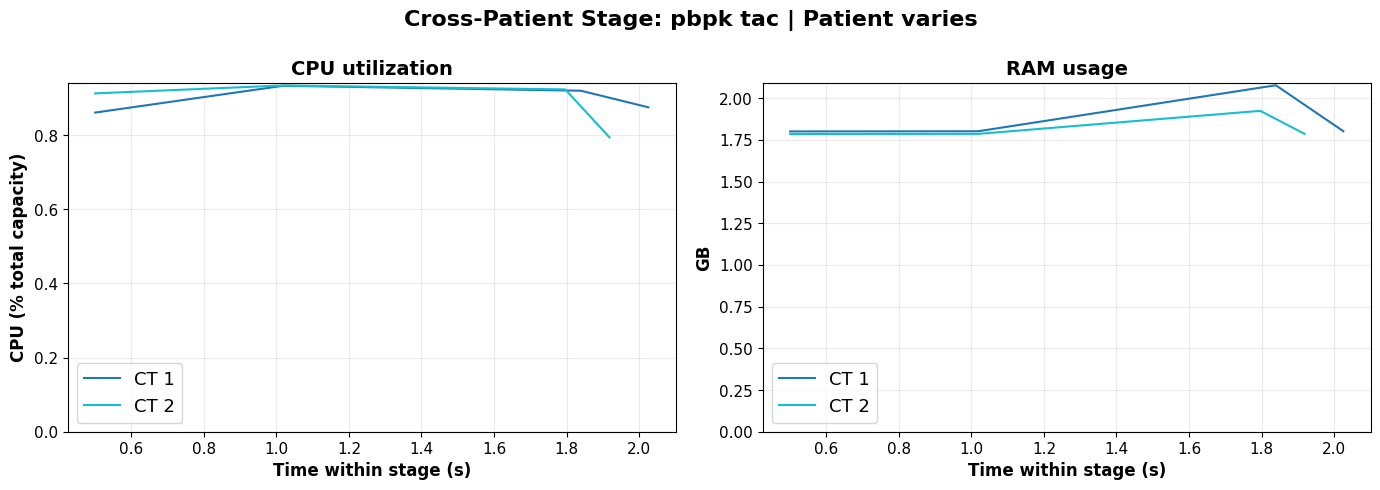

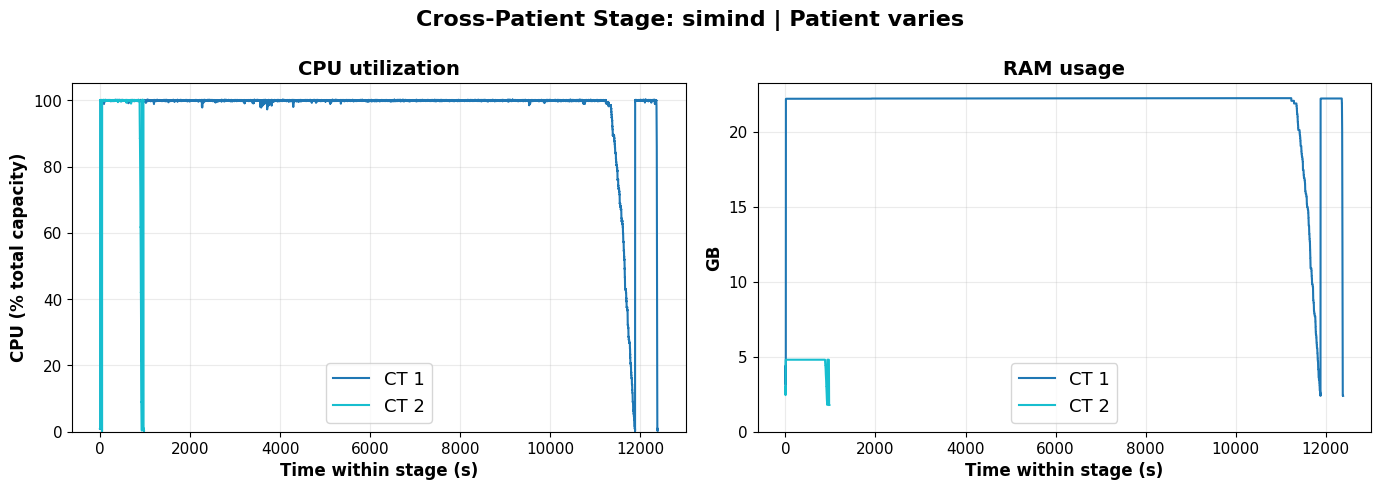

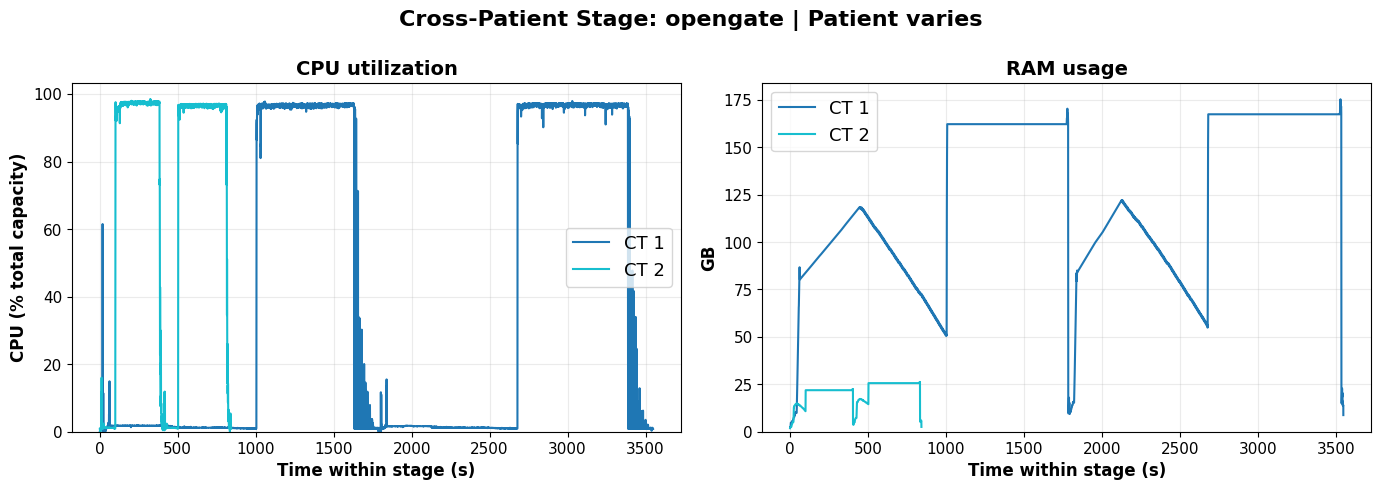

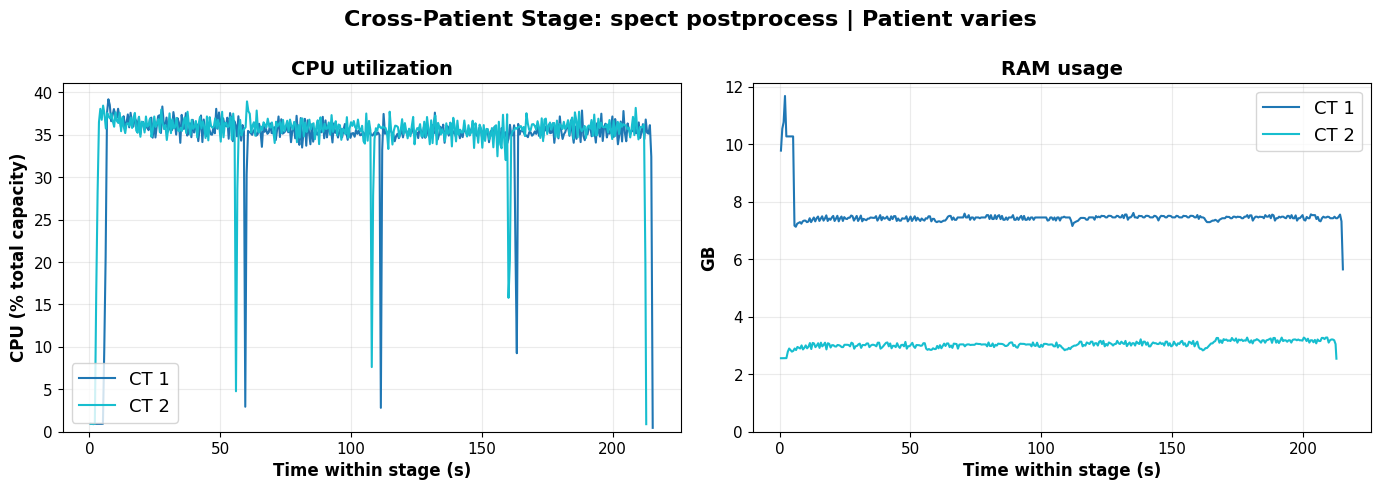

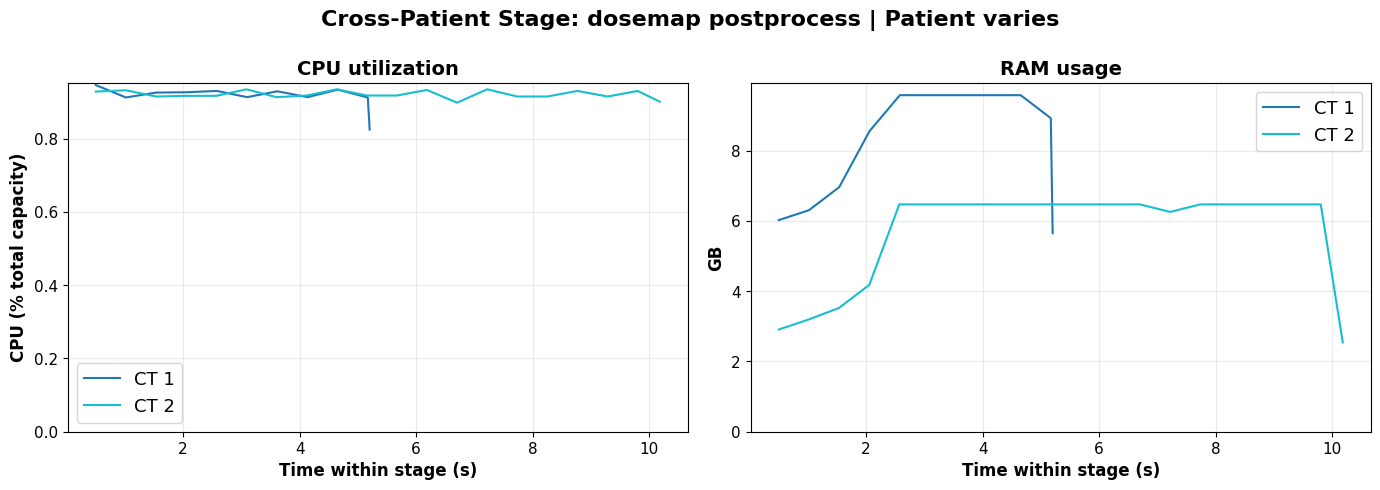

In [83]:
def ordered_stage_names(names):
    order = {name: idx for idx, name in enumerate(STAGE_ORDER)}
    return sorted(names, key=lambda n: (order.get(n, 10**6), n))

if len(profiles) > 1:
    def get_stages(prof, phase_filter):
        stages = prof.get('stages', [])
        return [x for x in stages if phase_filter.lower() in x.get('name', '').lower()] if phase_filter else stages

    all_stage_names = ordered_stage_names({s['name'] for prof in profiles.values() for s in get_stages(prof, PROFILE_PHASE)})
    if not all_stage_names:
        print(f"No stages match PROFILE_PHASE='{PROFILE_PHASE}'")
    else:
        patient_idxs = sorted(profiles.keys())
        colors = plt.get_cmap(plot_spec('profile', 'cmap', 'tab10'))(np.linspace(0, 1, len(patient_idxs)))

        for stage_name in all_stage_names:
            fig, (ax_cpu, ax_ram) = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(f'Cross-Patient Stage: {stage_name.replace("_", " ")} | {PARAM_LABEL} varies')

            for idx, col in zip(patient_idxs, colors):
                prof = profiles[idx]
                cpu_count = prof.get('logical_cpu_count', 1)
                match = [s for s in prof.get('stages', []) if s.get('name') == stage_name]
                if not match:
                    continue
                s = match[0]
                t = np.asarray(s.get('sample_times_s', []), dtype=float)
                cpu = np.asarray(s.get('cpu_pct_samples', []), dtype=float) / cpu_count
                ram = np.asarray(s.get('ram_mb_samples', []), dtype=float) / 1024.0
                if not t.size:
                    continue
                label = f'CT {idx+1}'
                ax_cpu.plot(t, cpu, lw=1.5, color=col, label=label)
                ax_ram.plot(t, ram, lw=1.5, color=col, label=label)

            ax_cpu.set_title('CPU utilization')
            ax_cpu.set_xlabel('Time within stage (s)')
            ax_cpu.set_ylabel('CPU (% total capacity)')
            ax_ram.set_title('RAM usage')
            ax_ram.set_xlabel('Time within stage (s)')
            ax_ram.set_ylabel('GB')
            for ax in (ax_cpu, ax_ram):
                ax.legend()
                ax.grid(True, alpha=0.25)
                ax.set_ylim(bottom=0)
            finish_plot(fig, f'profile_cross_patient_{stage_name}')
else:
    print('Only 1 patient - cross-patient profiling comparison skipped')


### 12c - Stage Runtime, CPU, and RAM Summary

Expected output: grouped bars for elapsed time, mean CPU capacity, and peak RAM across patients.


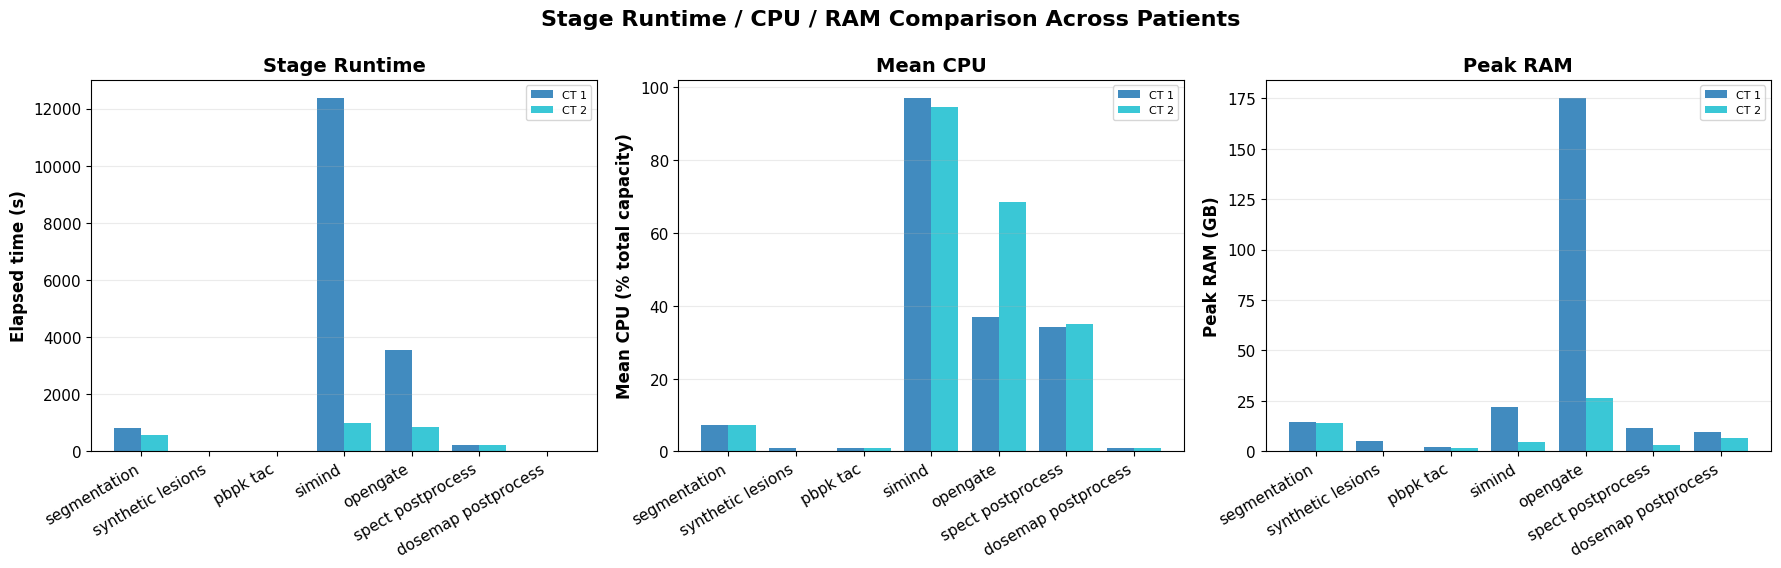

In [84]:
if profile_summary_store:
    all_names = ordered_stage_names({row['name'] for rows in profile_summary_store.values() for row in rows})
    patient_idxs = sorted(profile_summary_store.keys())
    x = np.arange(len(all_names))
    width = 0.8 / max(len(patient_idxs), 1)
    colors = plt.get_cmap(plot_spec('profile', 'cmap', 'tab10'))(np.linspace(0, 1, len(patient_idxs)))

    metrics = [
        ('elapsed_s', 'Elapsed time (s)', 'Stage Runtime'),
        ('mean_cpu_capacity_pct', 'Mean CPU (% total capacity)', 'Mean CPU'),
        ('peak_ram_gb', 'Peak RAM (GB)', 'Peak RAM'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))
    fig.suptitle('Stage Runtime / CPU / RAM Comparison Across Patients')

    for ax, (metric, ylabel, title) in zip(axes, metrics):
        for k, (idx, col) in enumerate(zip(patient_idxs, colors)):
            lookup = {row['name']: row.get(metric, np.nan) for row in profile_summary_store[idx]}
            vals = [lookup.get(n, np.nan) for n in all_names]
            off = (k - len(patient_idxs)/2 + 0.5) * width
            ax.bar(x + off, vals, width, label=f'CT {idx+1}', color=col, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels([n.replace('_', ' ') for n in all_names], rotation=30, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, axis='y', alpha=0.25)
        ax.legend(fontsize=8)
    finish_plot(fig, 'profile_stage_runtime_cpu_ram_summary')
else:
    print('No profiling summaries available')
